# IPL Match Intelligence System

### Predictive Analytics and Tactical Cricket Intelligence Using Machine Learning

 The Indian Premier League (IPL) is one of the most exciting and unpredictable T20 leagues, where matches can completely change within a few overs. A strong start does not always guarantee victory, and even high targets can be chased successfully with the right momentum, strategy, and pressure handling.

### This project explores the tactical side of IPL chases using:

Exploratory Data Analysis (EDA)

Pressure & Momentum Analysis

Statistical Insights

Machine Learning Models

SHAP Explainability


### The main goal of this project is to understand:

what makes IPL chases successful?

how pressure changes batting behavior?

why batting collapses happen?

which phases of the game are most important?

Instead of viewing IPL matches as completely random events, this project tries to uncover the hidden patterns and tactical decisions that influence chase outcomes. Through data storytelling and machine learning, the project transforms raw IPL data into meaningful cricket intelligence.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df= pd.read_csv("ipl.csv")

C:\Users\Hare kant jha\AppData\Local\Temp\ipykernel_20560\1486170954.py:1: DtypeWarning: Columns (0: season) have mixed types. Specify dtype option on import or set low_memory=False.
  df= pd.read_csv("ipl.csv")


In [4]:
df.head(3)

,match_id,date,season,event,venue,city,team1,team2,toss_winner,toss_decision,...,non_striker,runs_batter,runs_extras,runs_total,extras_wides,extras_noballs,extras_byes,extras_legbyes,wicket_kind,wicket_player_out
0,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,0,0,0,0,0,0,0,NaN,NaN
1,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,0,0,0,0,0,0,0,NaN,NaN
2,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,4,0,4,0,0,0,0,NaN,NaN


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 289673 entries, 0 to 289672
Data columns (total 30 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   match_id           289673 non-null  int64  
 1   date               289673 non-null  str    
 2   season             289673 non-null  object 
 3   event              289673 non-null  str    
 4   venue              289673 non-null  str    
 5   city               277276 non-null  str    
 6   team1              289673 non-null  str    
 7   team2              289673 non-null  str    
 8   toss_winner        289673 non-null  str    
 9   toss_decision      289673 non-null  str    
 10  winner             289673 non-null  str    
 11  win_by_runs        133547 non-null  float64
 12  win_by_wickets     151146 non-null  float64
 13  player_of_match    288845 non-null  str    
 14  innings            289673 non-null  int64  
 15  batting_team       289673 non-null  str    
 16  over         

In [6]:
df.describe()

,match_id,win_by_runs,win_by_wickets,innings,over,ball,runs_batter,runs_extras,runs_total,extras_wides,extras_noballs,extras_byes,extras_legbyes
count,2.896730e+05,133547.000000,151146.000000,289673.000000,289673.000000,289673.000000,289673.000000,289673.000000,289673.000000,289673.000000,289673.000000,289673.000000,289673.000000
mean,9.654832e+05,30.217766,6.115266,1.482793,9.190563,3.628167,1.285477,0.068184,1.353661,0.039565,0.004277,0.004705,0.019601
std,3.911715e+05,26.530801,1.823510,0.502495,5.680221,1.818353,1.659483,0.342671,1.645469,0.255822,0.068964,0.114363,0.190069
min,3.359820e+05,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.483650e+05,11.000000,5.000000,1.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.082626e+06,22.000000,6.000000,1.000000,9.000000,4.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,1.304085e+06,41.000000,7.000000,2.000000,14.000000,5.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,1.529292e+06,146.000000,10.000000,6.000000,19.000000,11.000000,6.000000,7.000000,7.000000,5.000000,5.000000,4.000000,5.000000


In [7]:
df.isnull().sum()

match_id                  0
date                      0
season                    0
event                     0
venue                     0
city                  12397
team1                     0
team2                     0
toss_winner               0
toss_decision             0
winner                    0
win_by_runs          156126
win_by_wickets       138527
player_of_match         828
innings                   0
batting_team              0
over                      0
ball                      0
batter                    0
bowler                    0
non_striker               0
runs_batter               0
runs_extras               0
runs_total                0
extras_wides              0
extras_noballs            0
extras_byes               0
extras_legbyes            0
wicket_kind          275267
wicket_player_out    275267
dtype: int64

In [8]:
df.shape

(289673, 30)

In [9]:
df['season'].unique()



array([2017, 2018, 2019, '2019', '2020/21', '2021', 2021, 2022, 2023,
       2024, 2025, '2025', '2007/08', '2009', '2009/10', '2011', 2011,
       2012, 2013, 2014, 2015, 2016, 2026], dtype=object)

In [10]:
df['season_year'] = (
    df['season']
    .astype(str)
    .str[:4]
    .astype(int)
)

In [11]:
df['season'] = df['season'].astype(str)

In [12]:
df['season'].unique()

<ArrowStringArray>
[   '2017',    '2018',    '2019', '2020/21',    '2021',    '2022',    '2023',
    '2024',    '2025', '2007/08',    '2009', '2009/10',    '2011',    '2012',
    '2013',    '2014',    '2015',    '2016',    '2026']
Length: 19, dtype: str

In [13]:
matches = df.drop_duplicates(subset='match_id')

In [14]:
matches.shape

(1218, 31)

In [15]:
matches.groupby('season')['match_id'].nunique()

season
2007/08    58
2009       57
2009/10    60
2011       73
2012       74
2013       76
2014       60
2015       59
2016       60
2017       59
2018       60
2019       60
2020/21    60
2021       60
2022       74
2023       74
2024       71
2025       74
2026       49
Name: match_id, dtype: int64

In [16]:
df['match_id'].nunique()

1218

In [17]:
matches['match_id'].nunique()

1218

In [18]:
matches[['match_id', 'season']].head()

,match_id,season
0,1082591,2017
248,1082592,2017
495,1082593,2017
713,1082594,2017
960,1082595,2017


In [19]:
df['event'].unique()

<ArrowStringArray>
['Indian Premier League']
Length: 1, dtype: str

In [20]:
matches.head()

,match_id,date,season,event,venue,city,team1,team2,toss_winner,toss_decision,...,runs_batter,runs_extras,runs_total,extras_wides,extras_noballs,extras_byes,extras_legbyes,wicket_kind,wicket_player_out,season_year
0,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,0,0,0,0,0,0,0,NaN,NaN,2017
248,1082592,2017-04-06,2017,Indian Premier League,Maharashtra Cricket Association Stadium,Pune,Rising Pune Supergiant,Mumbai Indians,Rising Pune Supergiant,field,...,0,1,1,1,0,0,0,NaN,NaN,2017
495,1082593,2017-04-07,2017,Indian Premier League,Saurashtra Cricket Association Stadium,Rajkot,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,...,0,0,0,0,0,0,0,NaN,NaN,2017
713,1082594,2017-04-08,2017,Indian Premier League,Holkar Cricket Stadium,Indore,Kings XI Punjab,Rising Pune Supergiant,Kings XI Punjab,field,...,1,0,1,0,0,0,0,NaN,NaN,2017
960,1082595,2017-04-08,2017,Indian Premier League,M.Chinnaswamy Stadium,Bengaluru,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,...,1,0,1,0,0,0,0,NaN,NaN,2017


In [21]:
matches[['season', 'winner']].head()


,season,winner
0,2017,Sunrisers Hyderabad
248,2017,Rising Pune Supergiant
495,2017,Kolkata Knight Riders
713,2017,Kings XI Punjab
960,2017,Royal Challengers Bangalore


# Do teams that win the toss actually win more matches?

In [22]:
toss_match_win = matches[
    matches['toss_winner'] == matches['winner']
]

In [23]:
percentage = (
    len(toss_match_win)
    /
    len(matches)
) * 100

print(percentage)

50.49261083743842


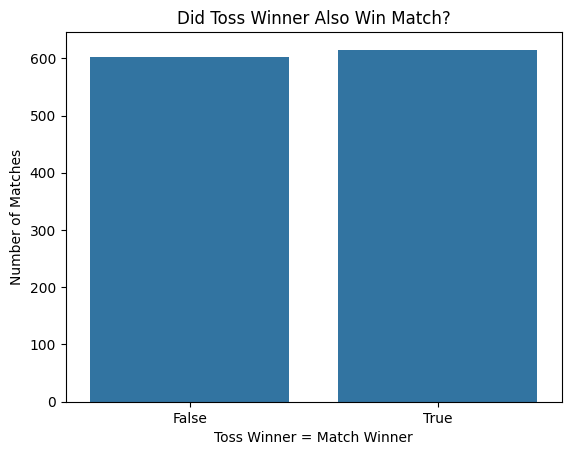

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(
    x=(matches['toss_winner'] == matches['winner'])
)

plt.title("Did Toss Winner Also Win Match?")
plt.xlabel("Toss Winner = Match Winner")
plt.ylabel("Number of Matches")

plt.savefig(
    'images/toss_analysis.png',
    bbox_inches='tight'
)

plt.show()

In [25]:
matches['toss_match_win'] = (
    matches['toss_winner'] == matches['winner']
)

In [26]:
season_toss = matches.groupby('season')['toss_match_win'].mean() * 100
season_toss

season
2007/08    48.275862
2009       57.894737
2009/10    51.666667
2011       52.054795
2012       44.594595
2013       46.052632
2014       48.333333
2015       45.762712
2016       56.666667
2017       57.627119
2018       53.333333
2019       56.666667
2020/21    41.666667
2021       56.666667
2022       48.648649
2023       45.945946
2024       43.661972
2025       58.108108
2026       48.979592
Name: toss_match_win, dtype: float64

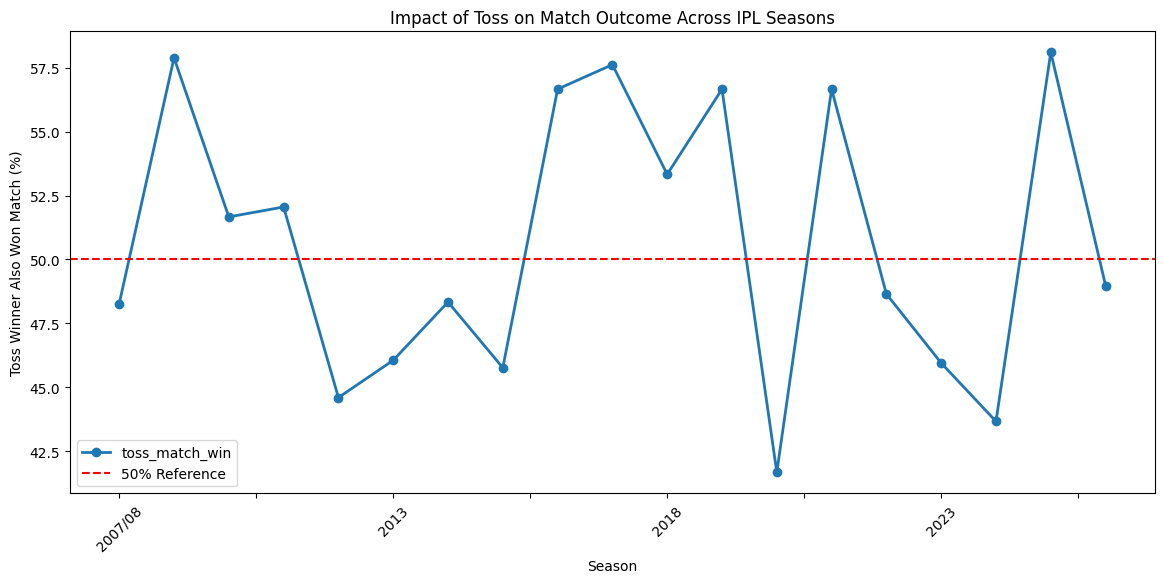

In [27]:
plt.figure(figsize=(14,6))

season_toss.plot(
    marker='o',
    linewidth=2
)

plt.axhline(
    y=50,
    color='red',
    linestyle='--',
    label='50% Reference'
)

plt.title("Impact of Toss on Match Outcome Across IPL Seasons")

plt.ylabel("Toss Winner Also Won Match (%)")

plt.xlabel("Season")

plt.xticks(rotation=45)

plt.legend()

plt.show()

### In IPL conversations, the toss is often treated as a game-changing moment — as if the match is decided before the first ball is even bowled.

However, the data tells a different story. Across IPL history, teams winning the toss also won the match only around 50% of the time, with the impact fluctuating heavily across seasons. Some years showed a slight advantage, while others remained nearly balanced.

This suggests that while the toss may influence strategy — especially in chase-friendly conditions — it is far from the defining factor behind victory. In modern IPL cricket, execution under pressure, middle-over control, and death-over performance appear to matter far more consistently than luck at the toss.


In [28]:
matches['toss_decision'].value_counts()

toss_decision
field    803
bat      415
Name: count, dtype: int64

In [29]:
decision_percent = (
    matches['toss_decision']
    .value_counts(normalize=True) * 100
)

print(decision_percent)

toss_decision
field    65.92775
bat      34.07225
Name: proportion, dtype: float64


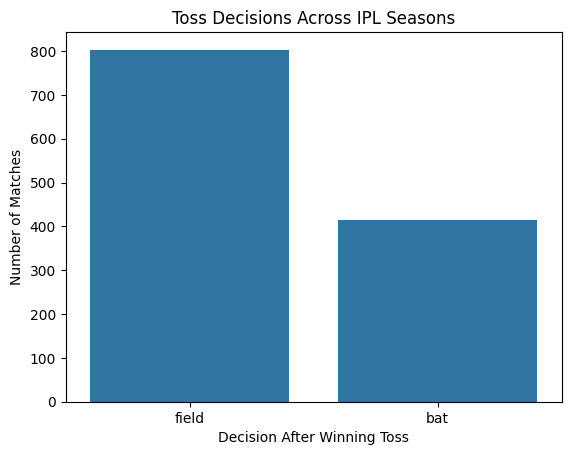

In [30]:
sns.countplot(
    x='toss_decision',
    data=matches
)

plt.title("Toss Decisions Across IPL Seasons")

plt.xlabel("Decision After Winning Toss")

plt.ylabel("Number of Matches")

plt.show()

In [31]:
matches['toss_decision_win'] = (
    matches['toss_winner'] == matches['winner']
)

In [32]:
decision_success = (
    matches.groupby('toss_decision')
    ['toss_decision_win']
    .mean() * 100
)

print(decision_success)

toss_decision
bat      44.337349
field    53.673724
Name: toss_decision_win, dtype: float64


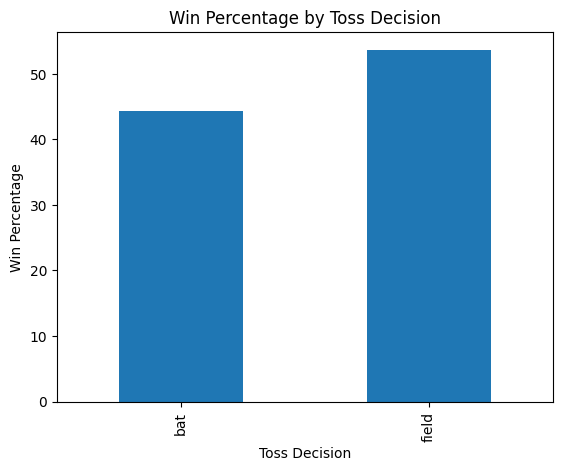

In [33]:
decision_success.plot(
    kind='bar'
)

plt.title("Win Percentage by Toss Decision")

plt.ylabel("Win Percentage")

plt.xlabel("Toss Decision")

plt.savefig(
    'images/toss_decision_impact.png',
    bbox_inches='tight'
)

plt.show()

### One of the clearest strategic patterns across IPL history is the growing preference for chasing. Nearly 66% of toss-winning teams chose to field first, highlighting how modern T20 teams value scoreboard awareness and chase flexibility over setting targets blindly.

Interestingly, this preference is also supported by results. Teams opting to bowl first after winning the toss recorded a noticeably higher win percentage compared to teams choosing to bat first.

The findings suggest that in the IPL, the toss itself may not guarantee victory — but the decision made after winning it can significantly influence match outcomes. Modern teams appear to trust chasing not just as a tactical preference, but as a statistically stronger pathway to victory.

# Phase-wise score analysis

### Which phase impacts victory the most — Powerplay, Middle Overs, or Death Overs?

In [34]:
df['phase'] = np.where(
    df['over'] <= 5,
    'Powerplay',
    np.where(
        df['over'] <= 14,
        'Middle Overs',
        'Death Overs'
    )
)

In [35]:
df['phase'].value_counts()

phase
Middle Overs    132841
Powerplay        91014
Death Overs      65818
Name: count, dtype: int64

In [36]:
over_runs = (
    df.groupby(
        ['match_id', 'innings', 'over', 'phase']
    )['runs_total']
    .sum()
    .reset_index()
)

In [37]:
over_runs.head()

,match_id,innings,over,phase,runs_total
0,335982,1,0,Powerplay,3
1,335982,1,1,Powerplay,18
2,335982,1,2,Powerplay,6
3,335982,1,3,Powerplay,23
4,335982,1,4,Powerplay,10


In [38]:
phase_runs_per_match = (
    df.groupby(
        ['match_id', 'innings', 'batting_team', 'phase']
    )['runs_total']
    .sum()
    .reset_index()
)
print(phase_runs_per_match.head())

   match_id  innings                 batting_team         phase  runs_total
0    335982        1        Kolkata Knight Riders   Death Overs          68
1    335982        1        Kolkata Knight Riders  Middle Overs          93
2    335982        1        Kolkata Knight Riders     Powerplay          61
3    335982        2  Royal Challengers Bangalore   Death Overs           1
4    335982        2  Royal Challengers Bangalore  Middle Overs          55


In [39]:
phase_avg = (
    phase_runs_per_match.groupby('phase')
    ['runs_total']
    .mean()
)
print(phase_avg)

phase
Death Overs     45.298831
Middle Overs    70.339123
Powerplay       47.663961
Name: runs_total, dtype: float64


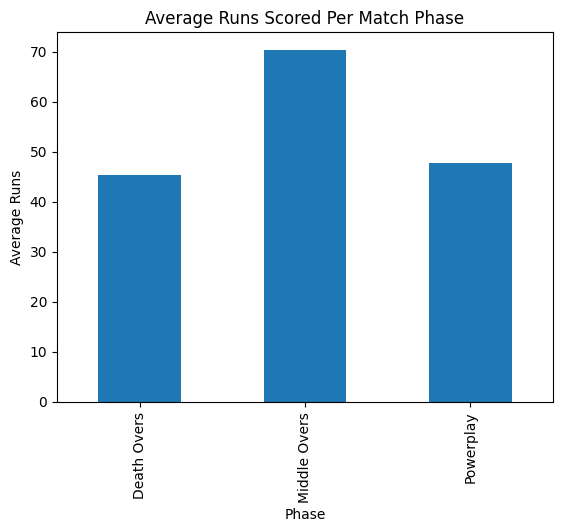

In [40]:
phase_avg.plot(kind='bar')

plt.title("Average Runs Scored Per Match Phase")

plt.ylabel("Average Runs")

plt.xlabel("Phase")
plt.savefig(
    'images/phase_avg.png',
    bbox_inches='tight'
)

plt.show()

In [41]:
phase_overs = {
    'Powerplay': 6,
    'Middle Overs': 9,
    'Death Overs': 5
}
```

In [42]:
intensity = phase_avg.copy()

for phase in intensity.index:
    intensity[phase] = (
        intensity[phase]
        /
        phase_overs[phase]
    )
    

In [43]:
print(intensity)

phase
Death Overs     9.059766
Middle Overs    7.815458
Powerplay       7.943994
Name: runs_total, dtype: float64


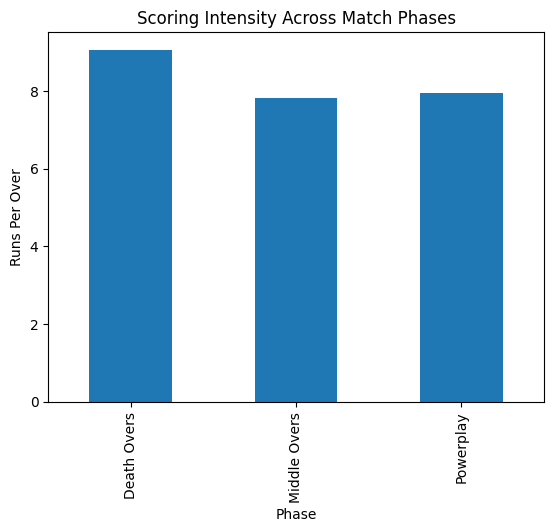

In [44]:
intensity.plot(kind='bar')

plt.title("Scoring Intensity Across Match Phases")

plt.ylabel("Runs Per Over")

plt.xlabel("Phase")
plt.savefig(
    'images/phase_intensity.png',
    bbox_inches='tight'
)

plt.show()

### The analysis reveals a clear shift in scoring intensity across IPL match phases. While middle overs contribute the largest share of runs overall, the most aggressive scoring occurs during the death overs, where teams score at an average rate exceeding 9 runs per over.

This highlights the growing importance of explosive finishing in modern T20 cricket. Teams appear to use the powerplay to establish momentum, stabilize innings during the middle overs, and then maximize acceleration in the final phase.

Interestingly, despite the attacking field restrictions during the powerplay, death overs still produce the highest scoring intensity, emphasizing how modern IPL batting strategies prioritize aggressive finishing over conservative wicket preservation.

In [45]:
match_winner = matches[
    ['match_id', 'winner']
]

In [46]:
phase_runs_per_match = (
    phase_runs_per_match.merge(
        match_winner,
        on='match_id'
    )
)

print(phase_runs_per_match.head())

   match_id  innings                 batting_team         phase  runs_total  \
0    335982        1        Kolkata Knight Riders   Death Overs          68   
1    335982        1        Kolkata Knight Riders  Middle Overs          93   
2    335982        1        Kolkata Knight Riders     Powerplay          61   
3    335982        2  Royal Challengers Bangalore   Death Overs           1   
4    335982        2  Royal Challengers Bangalore  Middle Overs          55   

                  winner  
0  Kolkata Knight Riders  
1  Kolkata Knight Riders  
2  Kolkata Knight Riders  
3  Kolkata Knight Riders  
4  Kolkata Knight Riders  


In [47]:
phase_runs_per_match['result'] = np.where(
    phase_runs_per_match['batting_team']
    ==
    phase_runs_per_match['winner'],

    'Winner',

    'Loser'
)

In [48]:
phase_runs_per_match.head()

,match_id,innings,batting_team,phase,runs_total,winner,result
0,335982,1,Kolkata Knight Riders,Death Overs,68,Kolkata Knight Riders,Winner
1,335982,1,Kolkata Knight Riders,Middle Overs,93,Kolkata Knight Riders,Winner
2,335982,1,Kolkata Knight Riders,Powerplay,61,Kolkata Knight Riders,Winner
3,335982,2,Royal Challengers Bangalore,Death Overs,1,Kolkata Knight Riders,Loser
4,335982,2,Royal Challengers Bangalore,Middle Overs,55,Kolkata Knight Riders,Loser


In [49]:
winner_phase = (
    phase_runs_per_match.groupby(
        ['phase', 'result']
    )['runs_total']
    .mean()
    .reset_index()
)

print(winner_phase)

          phase  result  runs_total
0   Death Overs   Loser   43.520332
1   Death Overs  Winner   47.240036
2  Middle Overs   Loser   66.488221
3  Middle Overs  Winner   74.332772
4     Powerplay   Loser   44.258851
5     Powerplay  Winner   51.291702


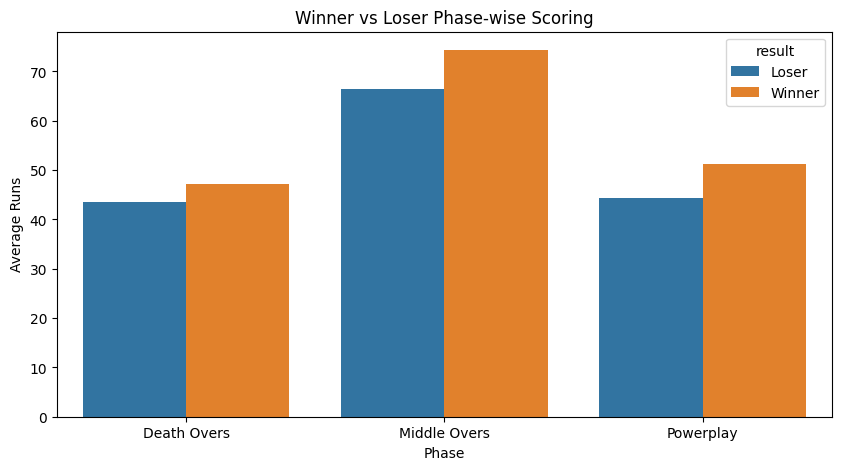

In [50]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=winner_phase,
    x='phase',
    y='runs_total',
    hue='result'
)

plt.title("Winner vs Loser Phase-wise Scoring")

plt.ylabel("Average Runs")

plt.xlabel("Phase")

plt.savefig(
    'images/winner_phase_comparison.png',
    bbox_inches='tight'
)

plt.show()

In [51]:
pivot_phase = winner_phase.pivot(
    index='phase',
    columns='result',
    values='runs_total'
)

In [52]:
pivot_phase['Difference'] = (
    pivot_phase['Winner']
    -
    pivot_phase['Loser']
)

In [53]:
print(pivot_phase)

result            Loser     Winner  Difference
phase                                         
Death Overs   43.520332  47.240036    3.719704
Middle Overs  66.488221  74.332772    7.844551
Powerplay     44.258851  51.291702    7.032850


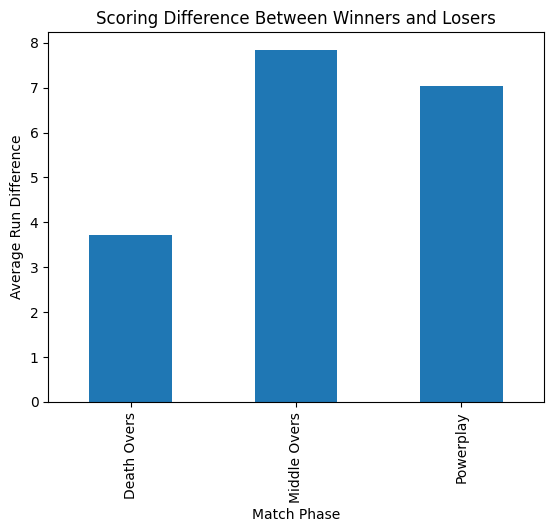

In [54]:
pivot_phase['Difference'].plot(
    kind='bar'
)

plt.title("Scoring Difference Between Winners and Losers")

plt.ylabel("Average Run Difference")

plt.xlabel("Match Phase")

plt.show()

### While death overs remain the most explosive scoring phase in IPL cricket, the largest performance gap between winning and losing teams actually appears during the middle overs.

Winning teams consistently outperform losing teams by nearly 8 runs in the middle phase, suggesting that sustained momentum and innings control between overs 7–15 may influence match outcomes more strongly than late-order acceleration alone.

Interestingly, the scoring gap during death overs is comparatively smaller, indicating that explosive finishing is common across teams, but middle-over stability and rotation often separate victories from defeats.

# Innings Pressure Dynamics

In [55]:
normal_df = df[df['innings'].isin([1, 2])]

In [56]:
innings_phase = (
   normal_df.groupby(
        ['match_id', 'innings', 'phase']
    )['runs_total']
    .sum()
    .reset_index()
)

In [57]:
innings_phase_avg = (
    innings_phase.groupby(
        ['innings', 'phase']
    )['runs_total']
    .mean()
    .reset_index()
)

In [58]:
print(innings_phase_avg)

   innings         phase  runs_total
0        1   Death Overs   50.522898
1        1  Middle Overs   70.810855
2        1     Powerplay   47.355501
3        2   Death Overs   39.636282
4        2  Middle Overs   69.861897
5        2     Powerplay   49.051155


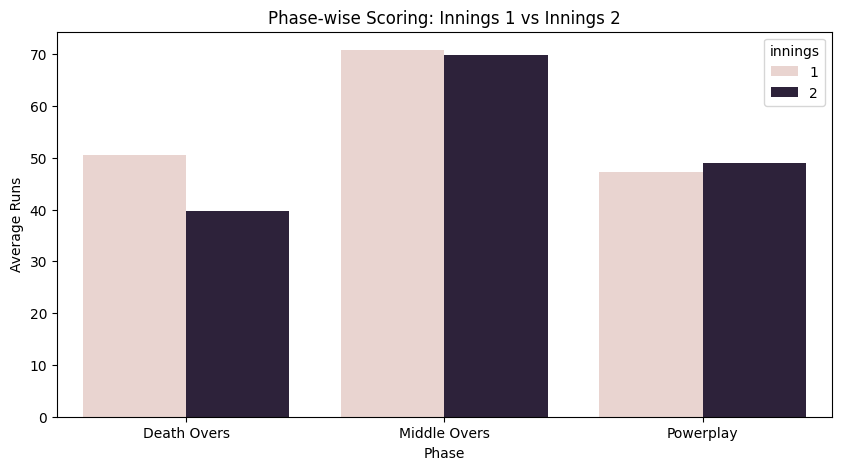

In [59]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=innings_phase_avg,
    x='phase',
    y='runs_total',
    hue='innings'
)

plt.title("Phase-wise Scoring: Innings 1 vs Innings 2")

plt.ylabel("Average Runs")

plt.xlabel("Phase")

plt.savefig(
    'images/innings_phase_comparison.png',
    bbox_inches='tight'
)

plt.show()

In [60]:
pivot_innings = innings_phase_avg.pivot(
    index='phase',
    columns='innings',
    values='runs_total'
)

In [61]:
pivot_innings['Difference'] = (
    pivot_innings[1]
    -
    pivot_innings[2]
)

In [62]:
print(pivot_innings)

innings               1          2  Difference
phase                                         
Death Overs   50.522898  39.636282   10.886616
Middle Overs  70.810855  69.861897    0.948958
Powerplay     47.355501  49.051155   -1.695654


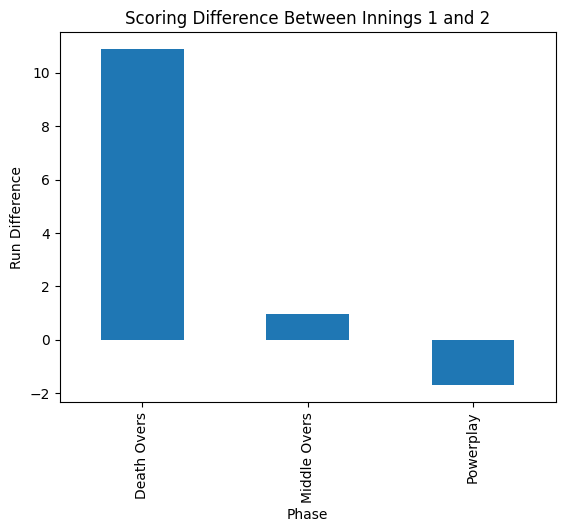

In [63]:
pivot_innings['Difference'].plot(
    kind='bar'
)

plt.title("Scoring Difference Between Innings 1 and 2")

plt.ylabel("Run Difference")

plt.xlabel("Phase")

plt.show()

### The phase-wise innings comparison reveals a fascinating shift in batting behavior under scoreboard pressure. Powerplay scoring remains relatively balanced across both innings, with chasing teams even scoring slightly faster early on, indicating aggressive intent during target pursuit.

However, the most dramatic difference emerges during the death overs. Teams batting first score nearly 11 more runs on average in the final phase compared to chasing teams. This suggests that first-innings teams bat with greater freedom and attacking intent, while second-innings teams often face scoreboard pressure, increased risk, or finish chases before fully utilizing the death overs.

Interestingly, middle-over scoring remains almost identical across innings, implying that the strategic balance of consolidation and strike rotation is largely consistent regardless of chase conditions.

Overall, the analysis indicates that scoreboard pressure influences IPL batting most heavily during the death overs, making late-innings execution one of the defining tactical differences between setting a target and chasing one.

## Winning Score Threshold

In [64]:
first_innings = (
    df[df['innings'] == 1]
    .groupby(
        ['match_id', 'batting_team']
    )['runs_total']
    .sum()
    .reset_index()
)

In [65]:
first_innings = (
    first_innings.merge(
        matches[['match_id', 'winner']],
        on='match_id'
    )
)

In [66]:
first_innings['defended'] = np.where(
    first_innings['batting_team']
    ==
    first_innings['winner'],

    1,

    0
)

In [67]:
bins = [0, 140, 160, 180, 200, 300]

labels = [
    '<140',
    '140-160',
    '160-180',
    '180-200',
    '200+'
]

first_innings['score_range'] = pd.cut(
    first_innings['runs_total'],
    bins=bins,
    labels=labels
)

In [68]:
score_analysis = (
    first_innings.groupby('score_range')
    ['defended']
    .mean() * 100
)
print(score_analysis)

score_range
<140       17.167382
140-160    27.799228
160-180    47.266881
180-200    60.360360
200+       76.683938
Name: defended, dtype: float64


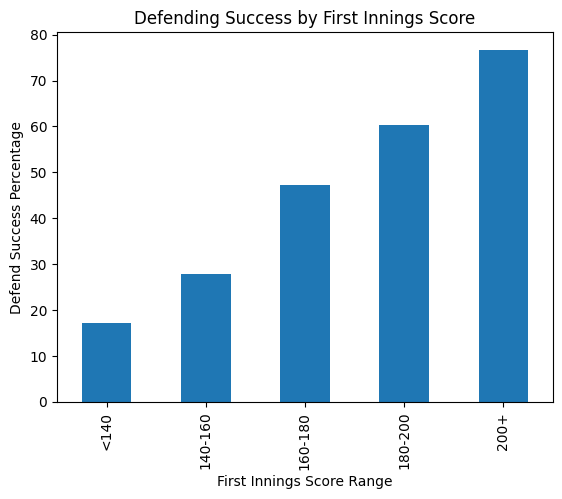

In [69]:
score_analysis.plot(kind='bar')

plt.title("Defending Success by First Innings Score")

plt.ylabel("Defend Success Percentage")

plt.xlabel("First Innings Score Range")

plt.savefig(
    'images/defending_success.png',
    bbox_inches='tight'
)

plt.show()

### IPL matches exhibit a clear scoreboard pressure threshold around the 180-run mark. While totals below 160 are frequently chased successfully, teams defending scores above 180 begin gaining a strong strategic advantage.

The defending success rate rises sharply from 47% in the 160–180 range to over 60% beyond 180, indicating that crossing the 180-run barrier substantially alters chase difficulty and batting pressure.

Extremely high totals above 200 prove even more dominant, with teams successfully defending them in over three-fourths of matches.

### Scoring 180+ significantly improves defending probability.

In [70]:
first_innings['high_score'] = np.where(
    first_innings['runs_total'] >= 180,
    '180+',
    '<180'
)

In [71]:
contingency = pd.crosstab(
    first_innings['high_score'],
    first_innings['defended']
)

print(contingency)

defended      0    1
high_score          
180+        137  287
<180        540  254


In [72]:
from scipy.stats import chi2_contingency

In [73]:
chi2, p, dof, expected = chi2_contingency(contingency)

print("P-value:", p)

P-value: 1.4296617939714263e-32


### The hypothesis test strongly rejects the assumption that defending success is independent of first-innings score.

With an extremely small p-value (1.42 × 10⁻³²), the analysis confirms a statistically significant relationship between crossing the 180-run mark and successful defense probability in IPL matches.

This validates the existence of a clear scoreboard pressure threshold in T20 cricket, where higher first-innings totals dramatically alter chase difficulty and match dynamics.

## Which factors correlate most with winning?

In [74]:
innings_summary = (
    df.groupby(
        ['match_id', 'innings']
    )
    .agg(
        total_runs=('runs_total', 'sum'),

        wickets=('wicket_kind', lambda x: x.notna().sum())
    )
    .reset_index()
)

In [75]:
phase_pivot = (
    phase_runs_per_match.pivot_table(
        index=['match_id', 'innings'],
        columns='phase',
        values='runs_total'
    )
    .reset_index()
)

In [76]:
analysis_df = (
    innings_summary.merge(
        phase_pivot,
        on=['match_id', 'innings']
    )
)

In [77]:
analysis_df.head()

,match_id,innings,total_runs,wickets,Death Overs,Middle Overs,Powerplay
0,335982,1,222,3,68.0,93.0,61.0
1,335982,2,82,10,1.0,55.0,26.0
2,335983,1,240,5,79.0,108.0,53.0
3,335983,2,207,4,42.0,102.0,63.0
4,335984,1,129,8,33.0,56.0,40.0


In [78]:
corr = analysis_df[
    [
        'total_runs',
        'wickets',
        'Powerplay',
        'Middle Overs',
        'Death Overs'
    ]
].corr()

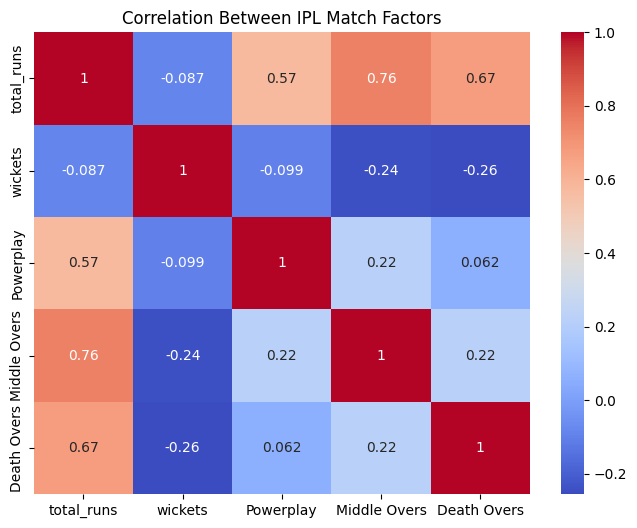

In [79]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Between IPL Match Factors")

plt.savefig(
    'images/correlation_heatmap.png',
    bbox_inches='tight'
)

plt.show()

### The correlation analysis reveals that middle-over performance has the strongest relationship with final innings totals, outperforming even powerplay and death-over contributions.

This suggests that while explosive starts and finishes remain important in T20 cricket, sustained scoring momentum during overs 7–15 plays the most significant role in building competitive totals.

Death-over scoring also shows a strong positive relationship with final scores, reinforcing the importance of finishing acceleration in modern IPL batting strategies.

Interestingly, wickets display a negative correlation with scoring, particularly during middle and death overs, indicating that preserving wickets remains critical for maintaining late-innings momentum.

# Venue Intelligence Analysis

In [80]:
venue_matches = matches[
    [
        'match_id',
        'venue',
        'winner',
        'team1',
        'team2',
        'toss_winner',
        'toss_decision'
    ]
]

In [81]:
first_innings_score = (
    df[df['innings'] == 1]
    .groupby(['match_id'])['runs_total']
    .sum()
    .reset_index()
)

In [82]:
first_innings_score = (
    first_innings_score.rename(
        columns={'runs_total': 'first_innings_total'}
    )
)

In [83]:
venue_analysis = (
    venue_matches.merge(
        first_innings_score,
        on='match_id'
    )
)

In [84]:
venue_scoring = (
    venue_analysis.groupby('venue')
    ['first_innings_total']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

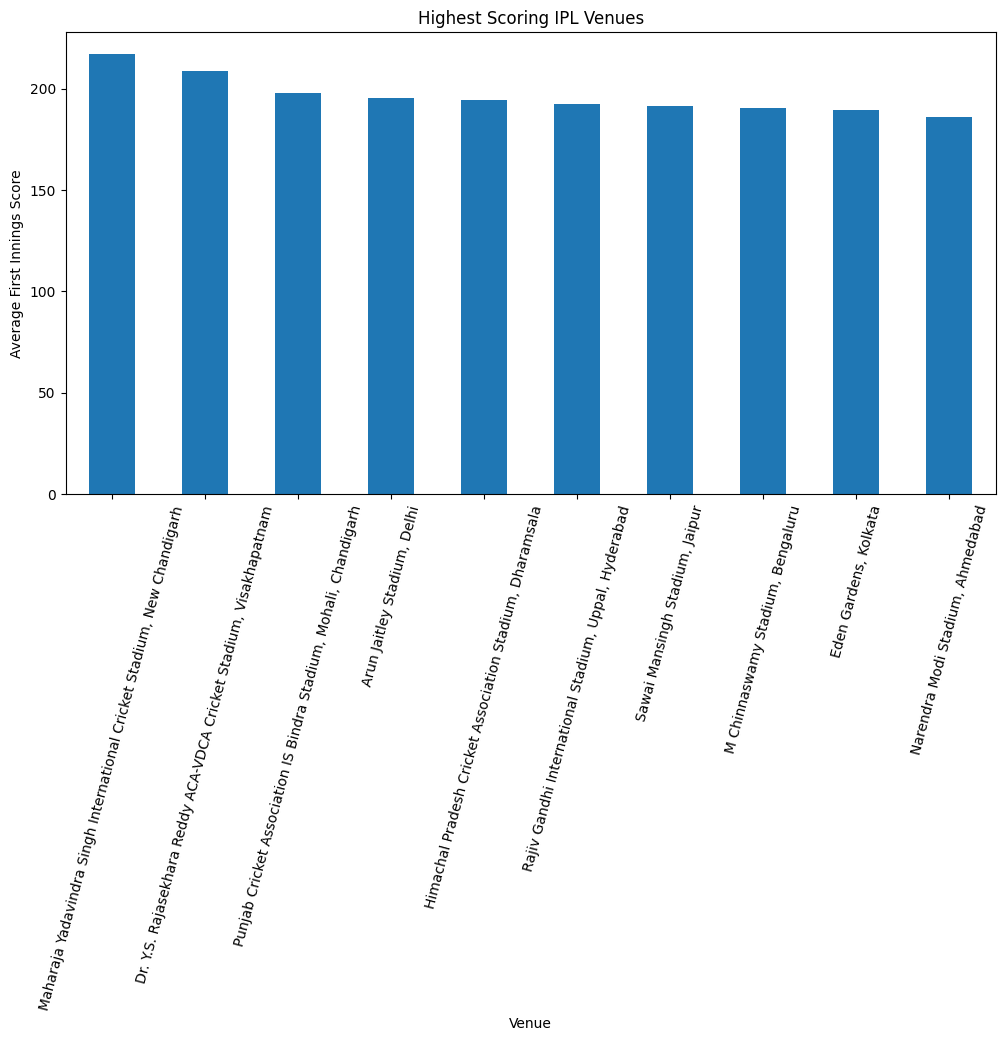

In [85]:
plt.figure(figsize=(12,6))

venue_scoring.plot(kind='bar')

plt.title("Highest Scoring IPL Venues")

plt.ylabel("Average First Innings Score")

plt.xlabel("Venue")

plt.xticks(rotation=75)

plt.savefig(
    'images/venue_analysis.png',
    bbox_inches='tight'
)
plt.show()

In [86]:
venue_analysis['chased'] = np.where(
    venue_analysis['winner']
    !=
    df.groupby('match_id')['batting_team'].first().values,

    1,

    0
)

In [87]:
venue_chasing = (
    venue_analysis.groupby('venue')
    ['chased']
    .mean() * 100
)

In [88]:
venue_count = (
    venue_analysis['venue']
    .value_counts()
)

valid_venues = venue_count[
    venue_count >= 15
].index

venue_chasing = (
    venue_chasing[
        venue_chasing.index.isin(valid_venues)
    ]
)

In [89]:
venue_chasing.sort_values(
    ascending=False
).head(10)

venue
Brabourne Stadium, Mumbai                  100.000000
Subrata Roy Sahara Stadium                 100.000000
Rajiv Gandhi International Stadium         100.000000
M.Chinnaswamy Stadium                      100.000000
Sharjah Cricket Stadium                     96.428571
Eden Gardens                                96.103896
Maharashtra Cricket Association Stadium     95.454545
M Chinnaswamy Stadium                       95.384615
Dr DY Patil Sports Academy, Mumbai          95.000000
Sawai Mansingh Stadium, Jaipur              94.736842
Name: chased, dtype: float64

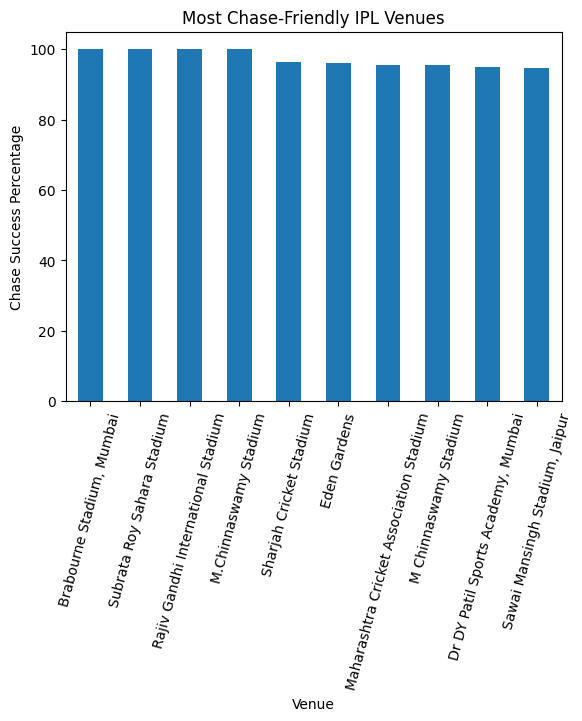

In [90]:
venue_chasing.sort_values(
    ascending=False
).head(10).plot(kind='bar')

plt.title("Most Chase-Friendly IPL Venues")

plt.ylabel("Chase Success Percentage")

plt.xlabel("Venue")

plt.xticks(rotation=75)

plt.show()

### The venue analysis reveals that certain IPL stadiums are overwhelmingly chase-friendly, with venues such as Brabourne Stadium, M. Chinnaswamy Stadium, and Sharjah Cricket Stadium recording exceptionally high chase success rates.

This strongly suggests that venue conditions play a critical role in shaping match dynamics and strategic decisions. Factors such as shorter boundaries, batting-friendly pitches, dew under lights, and fast outfields may significantly reduce the advantage of setting a target at these grounds.

Interestingly, many of the most chase-dominant venues are historically known for high-scoring matches, reinforcing the idea that aggressive batting conditions often favor teams pursuing targets with scoreboard clarity.

The findings also help explain why IPL captains overwhelmingly prefer bowling first after winning the toss. In certain venues, the strategic advantage of chasing becomes so strong that toss decisions are influenced not just by general T20 trends, but by venue-specific behavior patterns.

# Who are the top batters  across seasons?

In [91]:
batter_stats = (
    df.groupby('batter')
    .agg(
        runs=('runs_batter', 'sum'),

        balls=('ball', 'count'),

        matches=('match_id', 'nunique')
    )
)

In [92]:
batter_stats['strike_rate'] = (
    batter_stats['runs']
    /
    batter_stats['balls']
) * 100

In [93]:
top_batters = batter_stats[
    batter_stats['matches'] >= 30
]

In [94]:
top_batters.sort_values(
    by='runs',
    ascending=False
).head(10)

,runs,balls,matches,strike_rate
batter,,,,
V Kohli,9050,6942,268,130.365889
RG Sharma,7269,5605,271,129.687779
S Dhawan,6769,5483,221,123.454313
DA Warner,6567,4849,184,135.429986
KL Rahul,5680,4205,145,135.077289
SK Raina,5536,4177,200,132.535312
MS Dhoni,5439,4101,241,132.626189
AM Rahane,5237,4296,192,121.904097
AB de Villiers,5181,3487,170,148.580442


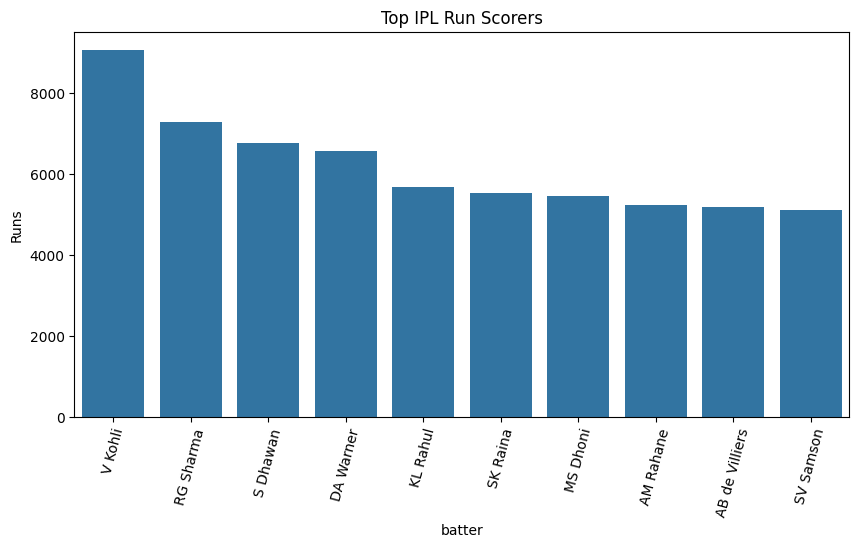

In [95]:
top10 = top_batters.sort_values(
    by='runs',
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top10.index,
    y=top10['runs']
)

plt.title("Top IPL Run Scorers")

plt.xticks(rotation=75)

plt.ylabel("Runs")
plt.savefig(
    'images/top_batters.png',
    bbox_inches='tight'
)

plt.show()

## The batting analysis highlights the evolution of IPL batting from traditional accumulation to high-intensity scoring.

Players such as Virat Kohli and Rohit Sharma dominate through exceptional consistency and longevity, accumulating massive run totals across multiple IPL eras. However, the data also reveals the growing importance of strike-rate efficiency in modern T20 cricket.

AB de Villiers stands out as one of the most impactful batters in IPL history, combining elite run production with an extraordinary strike rate approaching 150 — significantly higher than most high-volume scorers.

Interestingly, several modern-era batters such as KL Rahul and Sanju Samson maintain both strong consistency and aggressive scoring rates, reflecting the IPL’s strategic shift toward faster scoring and continuous pressure throughout innings.

## Who are the top bowlers across seasons?

In [96]:
bowler_stats = (
    df[df['wicket_kind'].notna()]
    .groupby('bowler')
    .agg(
        wickets=('wicket_kind', 'count'),

        matches=('match_id', 'nunique')
    )
)

In [97]:
top_bowlers = bowler_stats[
    bowler_stats['matches'] >= 30
]

In [98]:
top_bowlers.sort_values(
    by='wickets',
    ascending=False
).head(10)

,wickets,matches
bowler,,
YS Chahal,238,137
B Kumar,231,134
SP Narine,223,132
DJ Bravo,207,118
JJ Bumrah,207,104
R Ashwin,205,137
PP Chawla,201,128
SL Malinga,188,94
RA Jadeja,186,114


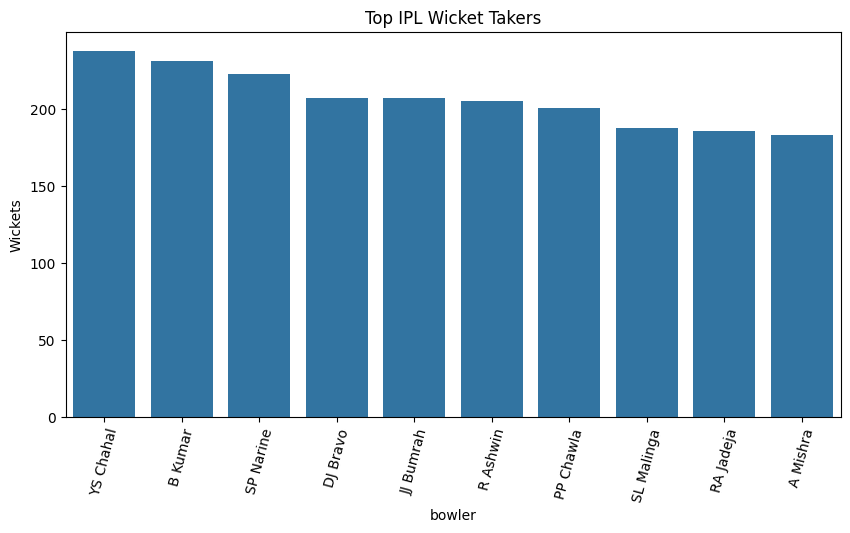

In [99]:
top10_bowlers = top_bowlers.sort_values(
    by='wickets',
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top10_bowlers.index,
    y=top10_bowlers['wickets']
)

plt.title("Top IPL Wicket Takers")

plt.xticks(rotation=75)

plt.ylabel("Wickets")

plt.savefig(
    'images/top_bowlers.png',
    bbox_inches='tight'
)

plt.show()

## The bowling analysis highlights the diverse tactical roles that successful IPL bowlers perform across match phases.

While bowlers such as Yuzvendra Chahal and Bhuvneshwar Kumar dominate through long-term consistency and sustained wicket-taking across seasons, others like Jasprit Bumrah and Lasith Malinga demonstrate extraordinary wicket efficiency despite playing fewer matches.

The data also reflects the strategic evolution of IPL bowling. Traditional control bowlers such as Sunil Narine and Ravichandran Ashwin excel through middle-over containment and pressure creation, while modern fast bowlers increasingly specialize in high-risk death-over execution.

Interestingly, many of the league’s most successful bowlers are not necessarily the most economical, but the ones capable of taking wickets during pressure phases — particularly in middle and death overs where match momentum shifts most dramatically.

# IPL Champions

In [100]:
all_teams = pd.concat([
    matches['team1'],
    matches['team2']
]).unique()

print(all_teams)

<ArrowStringArray>
[        'Sunrisers Hyderabad',      'Rising Pune Supergiant',
               'Gujarat Lions',             'Kings XI Punjab',
 'Royal Challengers Bangalore',              'Mumbai Indians',
       'Kolkata Knight Riders',            'Delhi Daredevils',
            'Rajasthan Royals',         'Chennai Super Kings',
              'Delhi Capitals',                'Punjab Kings',
        'Lucknow Super Giants',              'Gujarat Titans',
 'Royal Challengers Bengaluru',             'Deccan Chargers',
        'Kochi Tuskers Kerala',               'Pune Warriors',
     'Rising Pune Supergiants']
Length: 19, dtype: str


In [101]:
team_name_map = {

    'Delhi Daredevils':
    'Delhi Capitals',

    'Kings XI Punjab':
    'Punjab Kings',

    'Royal Challengers Bangalore':
    'Royal Challengers Bengaluru',

    'Rising Pune Supergiant':
    'Rising Pune Supergiants'
}

In [102]:
for col in [
    'team1',
    'team2',
    'winner',
    'toss_winner',
    'batting_team'
]:

    matches[col] = matches[col].replace(team_name_map)

    df[col] = df[col].replace(team_name_map)

In [103]:
all_teams = pd.concat([
    matches['team1'],
    matches['team2']
]).unique()

print(sorted(all_teams))

['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Gujarat Lions', 'Gujarat Titans', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiants', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']


In [104]:
final_matches = (
    matches.sort_values('date')
    .groupby('season')
    .tail(1)
)

In [105]:
champions = (
    final_matches['winner']
    .value_counts()
)

print(champions)

winner
Chennai Super Kings            5
Mumbai Indians                 5
Kolkata Knight Riders          3
Sunrisers Hyderabad            2
Rajasthan Royals               1
Deccan Chargers                1
Gujarat Titans                 1
Royal Challengers Bengaluru    1
Name: count, dtype: int64


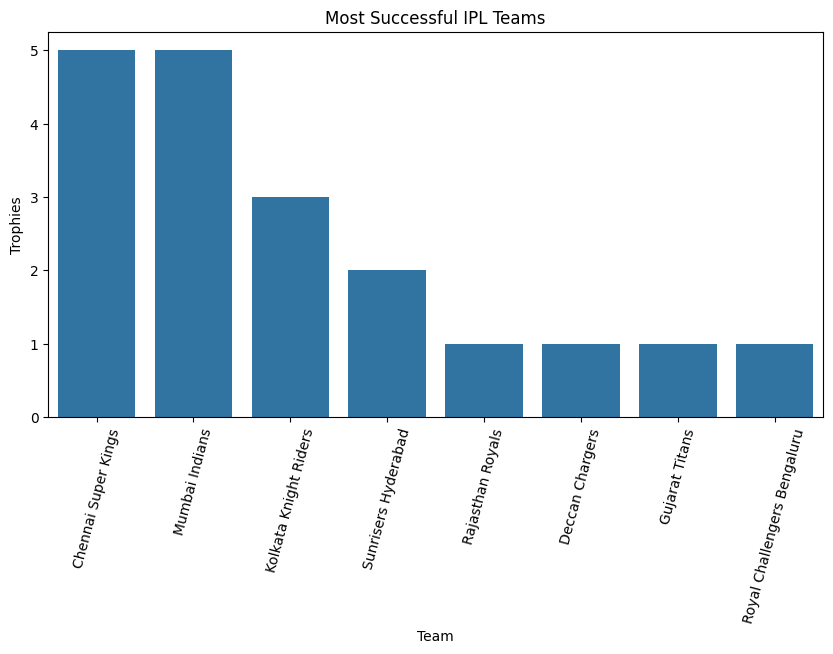

In [106]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=champions.index,
    y=champions.values
)

plt.title("Most Successful IPL Teams")

plt.ylabel("Trophies")

plt.xlabel("Team")

plt.xticks(rotation=75)

plt.savefig(
    'images/champions.png',
    bbox_inches='tight'
)


plt.show()

# Runs vs Strike Rate Scatter Plot

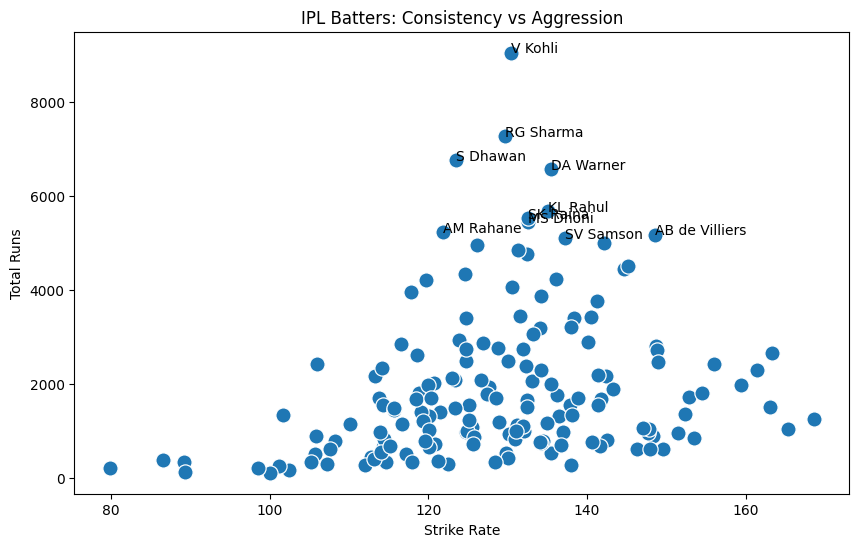

In [107]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=top_batters,
    x='strike_rate',
    y='runs',
    s=120
)

for player in top_batters.sort_values(
    by='runs',
    ascending=False
).head(10).index:

    x = top_batters.loc[player, 'strike_rate']
    y = top_batters.loc[player, 'runs']

    plt.text(x, y, player)

plt.title("IPL Batters: Consistency vs Aggression")

plt.xlabel("Strike Rate")

plt.ylabel("Total Runs")

plt.show()

### The scatter plot reveals the strategic evolution of batting in IPL cricket. Earlier batting approaches prioritized stability and innings construction, while modern T20 success increasingly depends on maintaining aggressive strike rates without sacrificing consistency.

Players such as Virat Kohli demonstrate exceptional long-term consistency across IPL eras, whereas AB de Villiers stands out as an extraordinary outlier capable of sustaining elite scoring aggression alongside massive run production.

Interestingly, many contemporary IPL stars cluster in the high-run, high-strike-rate region, reinforcing the league’s tactical transition toward continuous attacking intent throughout an innings rather than phase-specific acceleration alone.


In [108]:
# Step 1 → Create bowling stats

bowler_stats = (
    df[df['wicket_kind'].notna()]
    .groupby('bowler')
    .agg(
        wickets=('wicket_kind', 'count'),
        matches=('match_id', 'nunique')
    )
)

In [109]:
# Step 2 → Calculate wickets per match

bowler_stats['wickets_per_match'] = (
    bowler_stats['wickets']
    /
    bowler_stats['matches']
)

In [110]:
# Step 3 → Filter serious bowlers
# (to avoid random bowlers with few matches)

top_bowlers = bowler_stats[
    bowler_stats['matches'] >= 30
]


In [111]:
# Step 4 → Sort by wickets per match

top_wpm = (
    top_bowlers.sort_values(
        by='wickets_per_match',
        ascending=False
    )
    .head(10)
)


              wickets  matches  wickets_per_match
bowler                                           
MA Starc           81       37           2.189189
JO Holder          66       32           2.062500
JR Hazlewood       66       32           2.062500
MM Patel           82       41           2.000000
SL Malinga        188       94           2.000000
JJ Bumrah         207      104           1.990385
Imran Tahir        86       44           1.954545
K Rabada          144       74           1.945946
MM Sharma         149       78           1.910256
TG Southee         57       30           1.900000


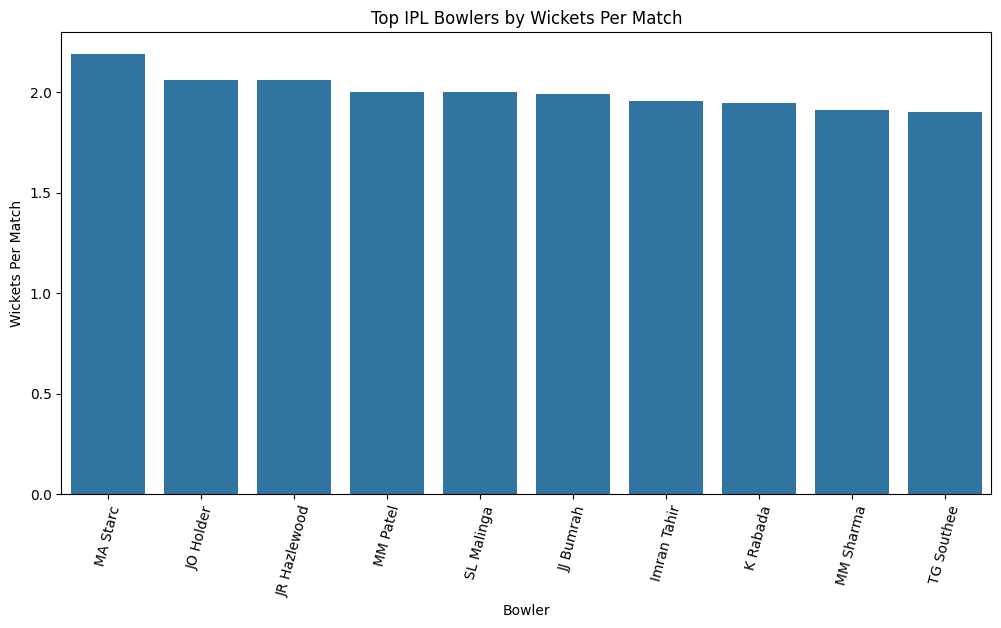

In [112]:

# Step 5 → Display result

print(top_wpm)

# Step 6 → Visualization

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_wpm.index,
    y=top_wpm['wickets_per_match']
)

plt.title("Top IPL Bowlers by Wickets Per Match")

plt.xlabel("Bowler")

plt.ylabel("Wickets Per Match")

plt.xticks(rotation=75)

plt.show()

### While long-term wicket tallies highlight bowling consistency across IPL seasons, wickets-per-match analysis reveals a different class of impact bowlers capable of influencing games immediately.

Mitchell Starc emerges as the most efficient wicket-taker among established IPL bowlers, averaging over two wickets per match — an extraordinary figure in the high-scoring T20 environment.

Interestingly, several bowlers dominating this metric, including Lasith Malinga and Jasprit Bumrah, are renowned for their effectiveness during pressure phases such as the death overs. This reinforces the broader project finding that controlling high-pressure phases remains one of the strongest determinants of IPL success.

The analysis also highlights the IPL’s tactical evolution toward aggressive wicket-taking rather than purely defensive containment, particularly in middle and death overs where momentum shifts most dramatically.

## Performing Under Pressure: IPL Clutch Players

### CLUTCH BATTERS

In [113]:

# DEATH OVER BATTERS


death_batting = df[
    df['phase'] == 'Death Overs'
]

# ==========================================
# BATTER STATS
# ==========================================

death_batter_stats = (
    death_batting.groupby('batter')
    .agg(
        runs=('runs_batter', 'sum'),

        balls=('ball', 'count'),

        matches=('match_id', 'nunique')
    )
)

# ==========================================
# STRIKE RATE
# ==========================================

death_batter_stats['strike_rate'] = (
    death_batter_stats['runs']
    /
    death_batter_stats['balls']
) * 100

# ==========================================
# FILTER SERIOUS PLAYERS
# ==========================================

death_batter_stats = death_batter_stats[
    death_batter_stats['matches'] >= 20
]

# ==========================================
# SORT
# ==========================================

top_clutch_batters = (
    death_batter_stats.sort_values(
        by='strike_rate',
        ascending=False
    )
    .head(10)
)

print(top_clutch_batters)

                runs  balls  matches  strike_rate
batter                                           
AB de Villiers  1868    867       81   215.455594
LS Livingstone   345    173       20   199.421965
T Stubbs         543    278       27   195.323741
CH Gayle         581    304       28   191.118421
RR Pant         1035    543       61   190.607735
Shashank Singh   489    260       28   188.076923
H Klaasen        734    398       36   184.422111
JC Buttler       750    407       42   184.275184
Ishan Kishan     366    200       27   183.000000
SV Samson        852    467       51   182.441113


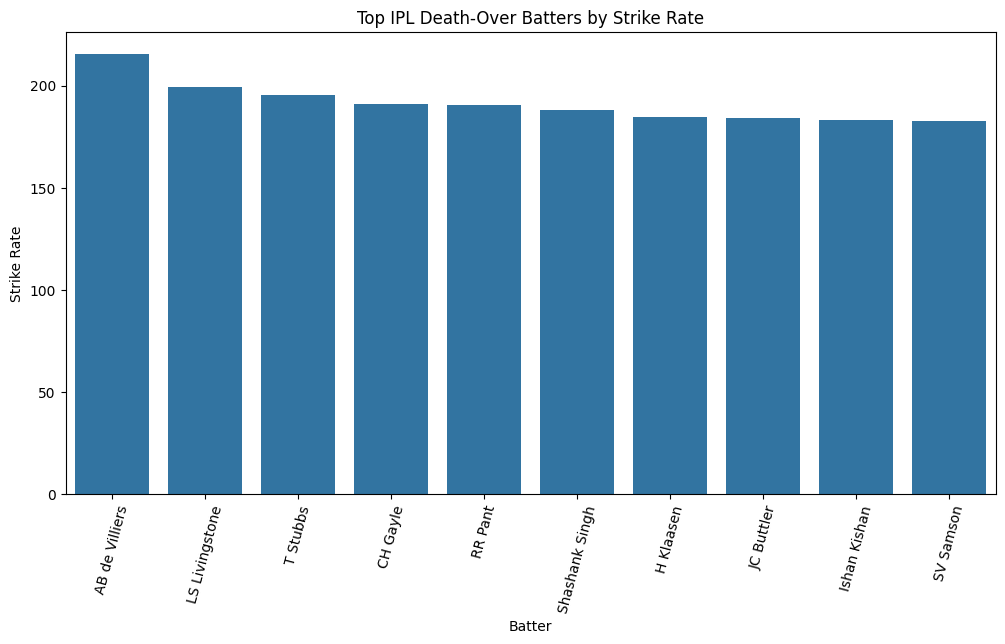

In [114]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_clutch_batters.index,
    y=top_clutch_batters['strike_rate']
)

plt.title(
    "Top IPL Death-Over Batters by Strike Rate"
)

plt.ylabel("Strike Rate")

plt.xlabel("Batter")

plt.xticks(rotation=75)

plt.savefig(
    'images/clutch_batters.png',
    bbox_inches='tight'
)

plt.show()

### CLUTCH BOWLERS

In [115]:
# ==========================================
# DEATH OVER BOWLERS
# ==========================================

death_bowling = df[
    df['phase'] == 'Death Overs'
]

# ==========================================
# BOWLER STATS
# ==========================================

death_bowler_stats = (
    death_bowling.groupby('bowler')
    .agg(
        wickets=('wicket_kind', lambda x: x.notna().sum()),

        runs_conceded=('runs_total', 'sum'),

        balls=('ball', 'count'),

        matches=('match_id', 'nunique')
    )
)

# ==========================================
# ECONOMY RATE
# ==========================================

death_bowler_stats['overs'] = (
    death_bowler_stats['balls'] / 6
)

death_bowler_stats['economy'] = (
    death_bowler_stats['runs_conceded']
    /
    death_bowler_stats['overs']
)

# ==========================================
# FILTER SERIOUS BOWLERS
# ==========================================

death_bowler_stats = death_bowler_stats[
    death_bowler_stats['matches'] >= 20
]

# ==========================================
# SORT BY WICKETS
# ==========================================

top_clutch_bowlers = (
    death_bowler_stats.sort_values(
        by='wickets',
        ascending=False
    )
    .head(10)
)

print(top_clutch_bowlers)

                wickets  runs_conceded  balls  matches       overs    economy
bowler                                                                       
DJ Bravo            130           2198   1463      129  243.833333   9.014354
B Kumar             125           2423   1611      162  268.500000   9.024209
SL Malinga          122           1526   1174      114  195.666667   7.798978
JJ Bumrah           115           1964   1455      138  242.500000   8.098969
HV Patel             93           1456    920       90  153.333333   9.495652
SP Narine            91           1345   1104      138  184.000000   7.309783
Mohammed Shami       79           1290    740       89  123.333333  10.459459
MM Sharma            75           1393    840       89  140.000000   9.950000
Sandeep Sharma       72           1388    833       98  138.833333   9.997599
YS Chahal            71           1058    698      103  116.333333   9.094556


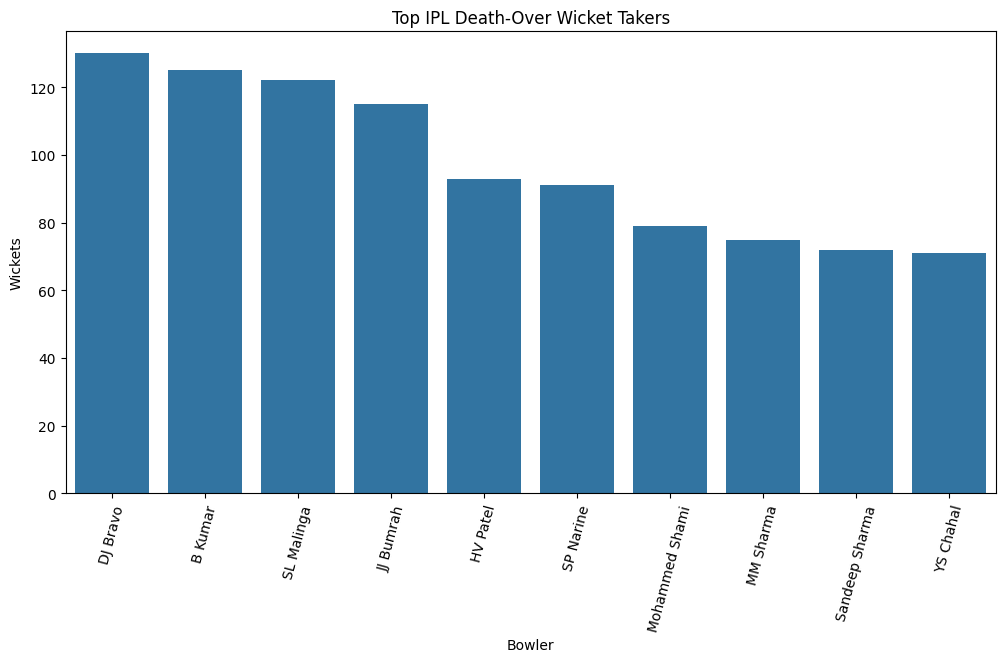

In [116]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_clutch_bowlers.index,
    y=top_clutch_bowlers['wickets']
)

plt.title(
    "Top IPL Death-Over Wicket Takers"
)

plt.ylabel("Wickets")

plt.xlabel("Bowler")

plt.xticks(rotation=75)

plt.savefig(
    'images/clutch_bowlers.png',
    bbox_inches='tight'
)

plt.show()


## The clutch-performance analysis strongly aligns with real-world IPL reputation patterns, validating the effectiveness of the analytical framework.

AB de Villiers emerges as the most explosive high-volume death-over batter, sustaining an extraordinary strike rate above 215 despite operating under the league’s highest-pressure scoring conditions. Modern finishers such as Klaasen, Stubbs, and Livingstone similarly dominate the aggressive acceleration zone, reflecting the IPL’s evolution toward relentless late-innings power hitting.

On the bowling side, specialists such as Lasith Malinga, Jasprit Bumrah, and Sunil Narine stand out for maintaining exceptional control and wicket-taking ability during the most volatile overs in T20 cricket. Their unusually low death-over economy rates highlight the tactical importance of execution under scoreboard pressure.

Interestingly, many players identified as elite clutch performers are closely associated with historically successful IPL franchises, reinforcing the broader project conclusion that mastering high-pressure phases remains central to sustained tournament success.

## Do middle-over wickets reduce death-over acceleration?

In [117]:
middle_wickets = (
    df[
        (df['phase'] == 'Middle Overs')
        &
        (df['wicket_kind'].notna())
    ]
    .groupby(['match_id', 'innings'])
    .size()
    .reset_index(name='middle_wickets')
)

In [118]:
death_runs = (
    df[df['phase'] == 'Death Overs']
    .groupby(['match_id', 'innings'])
    ['runs_total']
    .sum()
    .reset_index(name='death_runs')
)

In [119]:
collapse_analysis = (
    death_runs.merge(
        middle_wickets,
        on=['match_id', 'innings'],
        how='left'
    )
)

In [120]:
collapse_analysis['middle_wickets'] = (
    collapse_analysis['middle_wickets']
    .fillna(0)
)

In [121]:
collapse_analysis['wicket_group'] = pd.cut(

    collapse_analysis['middle_wickets'],

    bins=[-1, 1, 3, 10],

    labels=[
        '0-1 wickets',
        '2-3 wickets',
        '4+ wickets'
    ]
)

In [122]:
momentum_result = (
    collapse_analysis.groupby('wicket_group')
    ['death_runs']
    .mean()
)

In [123]:
print(momentum_result)

wicket_group
0-1 wickets    47.272586
2-3 wickets    46.718970
4+ wickets     37.303109
Name: death_runs, dtype: float64


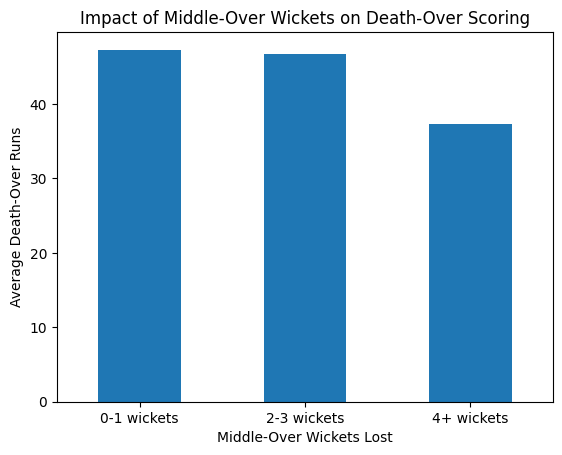

In [124]:
momentum_result.plot(kind='bar')

plt.title(
    "Impact of Middle-Over Wickets on Death-Over Scoring"
)

plt.xlabel("Middle-Over Wickets Lost")

plt.ylabel("Average Death-Over Runs")

plt.xticks(rotation=0)

plt.savefig(
    'images/momentum.png',
    bbox_inches='tight'
)

plt.show()

### The momentum-collapse analysis reveals that moderate wicket losses during the middle overs do not significantly reduce death-over scoring potential. However, once teams lose four or more wickets between overs 7–15, death-over acceleration declines sharply.

Teams preserving wickets during the middle phase consistently maintain stronger finishing capability, averaging nearly 10 additional death-over runs compared to innings suffering major middle-over collapses.

This suggests that middle overs function as the structural backbone of T20 innings construction. Rather than serving purely as a consolidation phase, the middle overs determine whether teams retain sufficient batting depth to execute aggressive death-over acceleration.

The findings strongly reinforce earlier project insights identifying middle overs as the most influential phase in determining IPL match outcomes and total scoring potential.

## What separates successful chases from failed chases?

In [125]:
innings2 = df[df['innings'] == 2]

In [126]:
chase_phase = (
    innings2.groupby(
        ['match_id', 'batting_team', 'phase']
    )['runs_total']
    .sum()
    .reset_index()
)

In [127]:
chase_phase = (
    chase_phase.merge(
        matches[['match_id', 'winner']],
        on='match_id'
    )
)

In [128]:
chase_phase['chase_result'] = np.where(

    chase_phase['batting_team']
    ==
    chase_phase['winner'],

    'Successful Chase',

    'Failed Chase'
)


In [129]:
chase_analysis = (
    chase_phase.groupby(
        ['phase', 'chase_result']
    )['runs_total']
    .mean()
    .reset_index()
)
print(chase_analysis)

          phase      chase_result  runs_total
0   Death Overs      Failed Chase   40.101664
1   Death Overs  Successful Chase   39.192240
2  Middle Overs      Failed Chase   67.561151
3  Middle Overs  Successful Chase   71.842105
4     Powerplay      Failed Chase   45.971429
5     Powerplay  Successful Chase   51.696319


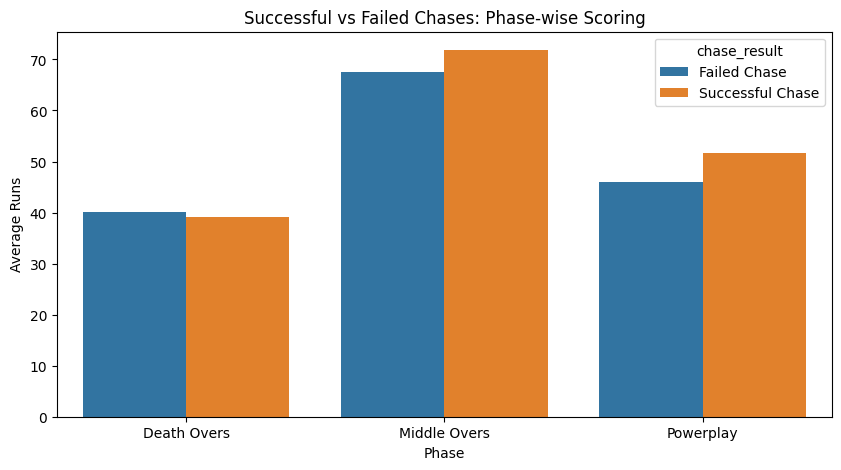

In [130]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=chase_analysis,
    x='phase',
    y='runs_total',
    hue='chase_result'
)

plt.title(
    "Successful vs Failed Chases: Phase-wise Scoring"
)

plt.ylabel("Average Runs")

plt.xlabel("Phase")

plt.savefig(
    'images/chase_analysis.png',
    bbox_inches='tight'
)

plt.show()


### Wicket impact

In [131]:
chase_wickets = (
    innings2.groupby(
        ['match_id', 'batting_team']
    )['wicket_kind']
    .apply(lambda x: x.notna().sum())
    .reset_index(name='wickets_lost')
)

In [132]:
chase_wickets = (
    chase_wickets.merge(
        matches[['match_id', 'winner']],
        on='match_id'
    )
)


In [133]:
chase_wickets['chase_result'] = np.where(

    chase_wickets['batting_team']
    ==
    chase_wickets['winner'],

    'Successful Chase',

    'Failed Chase'
)


In [134]:
wicket_analysis = (
    chase_wickets.groupby(
        'chase_result'
    )['wickets_lost']
    .mean()
    .reset_index()
)

print(wicket_analysis)

       chase_result  wickets_lost
0      Failed Chase      7.891071
1  Successful Chase      3.805215


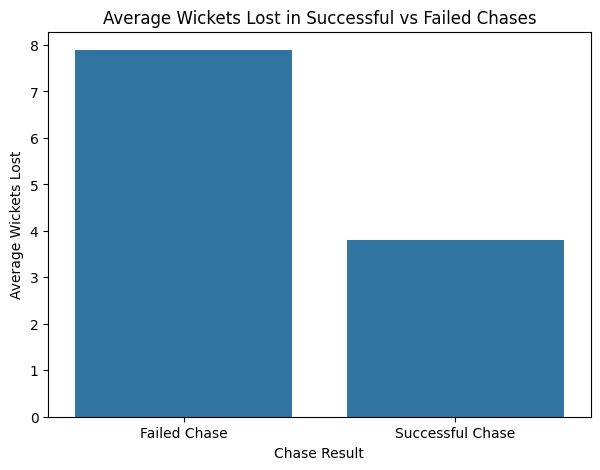

In [135]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=wicket_analysis,
    x='chase_result',
    y='wickets_lost'
)

plt.title(
    "Average Wickets Lost in Successful vs Failed Chases"
)

plt.ylabel("Average Wickets Lost")

plt.xlabel("Chase Result")


plt.show()

### The chase analysis reveals that successful IPL chases are built less on reckless finishing and more on controlled momentum throughout the innings. Winning chasing teams consistently score higher during both the powerplay and middle overs, establishing stronger scoring stability before the final phase.

Interestingly, death-over scoring remains nearly identical between successful and failed chases, suggesting that most chase outcomes are often decided earlier rather than during last-over acceleration alone.

The wicket analysis reinforces this pattern dramatically. Failed chases lose nearly twice as many wickets on average compared to successful chases, indicating that wicket preservation plays a critical role in handling scoreboard pressure.

Collectively, the findings suggest that successful IPL chases rely on maintaining middle-over stability, preserving batting depth, and avoiding momentum collapses rather than depending solely on explosive death-over hitting.

## psychological/tactical analytics

### How do teams perform under high-pressure situations?

In [136]:
first_innings_score = (
    df[df['innings'] == 1]
    .groupby('match_id')
    ['runs_total']
    .sum()
    .reset_index(name='target')
)

# add +1 because chase target
first_innings_score['target'] += 1

In [137]:
innings2 = df[df['innings'] == 2].copy()

In [138]:
innings2 = innings2.merge(
    first_innings_score,
    on='match_id'
)

In [139]:
innings2['ball_number'] = (
    (innings2['over'] * 6)
    +
    innings2['ball']
)

In [140]:
innings2['current_score'] = (
    innings2.groupby('match_id')
    ['runs_total']
    .cumsum()
)

In [141]:
innings2['runs_remaining'] = (
    innings2['target']
    -
    innings2['current_score']
)

In [142]:
innings2['balls_remaining'] = (
    120
    -
    innings2['ball_number']
)

In [143]:
innings2['required_rr'] = (
    innings2['runs_remaining']
    /
    (innings2['balls_remaining'] / 6)
)

In [144]:
innings2['wicket'] = (
    innings2['wicket_kind']
    .notna()
    .astype(int)
)

innings2['wickets_lost'] = (
    innings2.groupby('match_id')
    ['wicket']
    .cumsum()
)

In [145]:
innings2['pressure_index'] = (

    innings2['required_rr']

    *

    (innings2['wickets_lost'] + 1)

)

In [146]:
innings2['pressure_group'] = pd.cut(

    innings2['pressure_index'],

    bins=[0, 10, 25, 50, 500],

    labels=[
        'Low Pressure',
        'Moderate Pressure',
        'High Pressure',
        'Extreme Pressure'
    ]
)

In [147]:
pressure_analysis = (
    innings2.groupby('pressure_group')
    ['runs_total']
    .mean()
)

print(pressure_analysis)

pressure_group
Low Pressure         1.419837
Moderate Pressure    1.319082
High Pressure        1.277768
Extreme Pressure     1.340417
Name: runs_total, dtype: float64


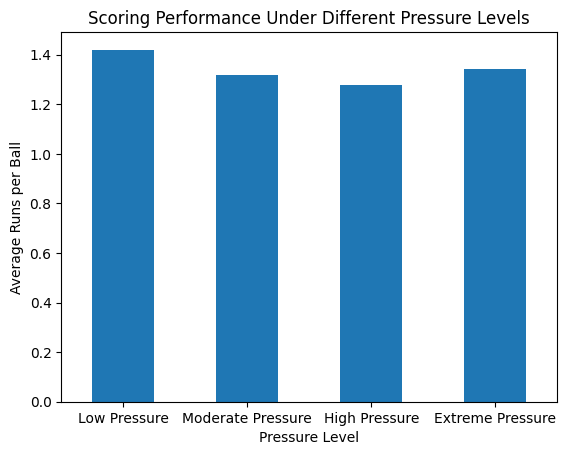

In [148]:
pressure_analysis.plot(kind='bar')

plt.title(
    "Scoring Performance Under Different Pressure Levels"
)

plt.ylabel("Average Runs per Ball")

plt.xlabel("Pressure Level")

plt.xticks(rotation=0)

plt.savefig(
    'images/pressure_analysis.png',
    bbox_inches='tight'
)

plt.show()

### There is not significant difference because it take avarage of all run in  overs 

# Do teams lose wickets more frequently under pressure?

In [149]:
pressure_wickets = (
    innings2.groupby('pressure_group')
    ['wicket']
    .mean() * 100
)

print(pressure_wickets)

pressure_group
Low Pressure         0.532259
Moderate Pressure    4.223904
High Pressure        5.624645
Extreme Pressure     8.730438
Name: wicket, dtype: float64


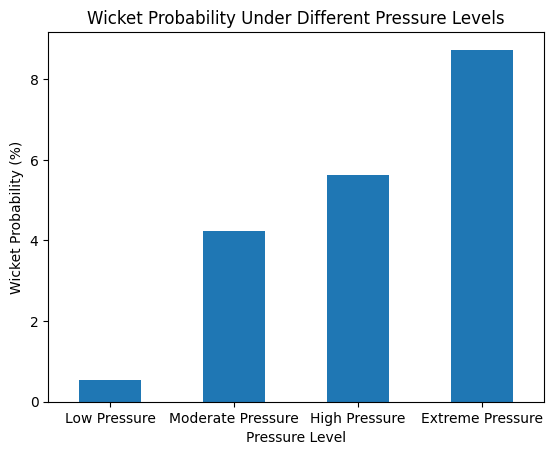

In [150]:
pressure_wickets.plot(kind='bar')

plt.title(
    "Wicket Probability Under Different Pressure Levels"
)

plt.ylabel("Wicket Probability (%)")

plt.xlabel("Pressure Level")

plt.xticks(rotation=0)

plt.show()

## Do batters attack more aggressively under pressure?

In [151]:
innings2['boundary'] = np.where(
    innings2['runs_batter'] >= 4,
    1,
    0
)

pressure_boundary = (
    innings2.groupby('pressure_group')
    ['boundary']
    .mean() * 100
)

print(pressure_boundary)

pressure_group
Low Pressure         20.513558
Moderate Pressure    17.019437
High Pressure        14.576945
Extreme Pressure     15.038244
Name: boundary, dtype: float64


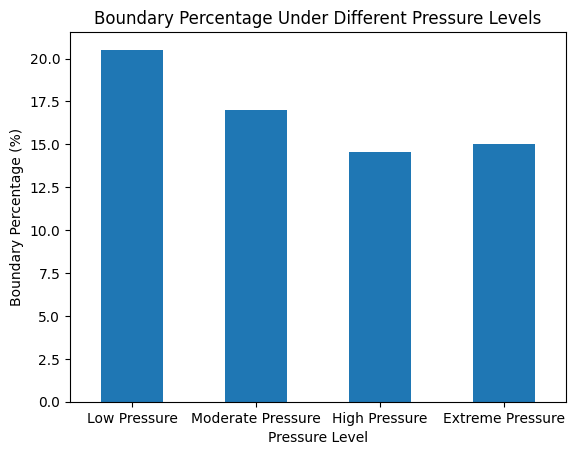

In [152]:
pressure_boundary.plot(kind='bar')

plt.title(
    "Boundary Percentage Under Different Pressure Levels"
)

plt.ylabel("Boundary Percentage (%)")

plt.xlabel("Pressure Level")

plt.xticks(rotation=0)

plt.show()

### The Pressure Index analysis reveals a fascinating shift in batting behavior during IPL chases. Contrary to common expectation, scoring rates do not collapse dramatically under pressure. Instead, teams continue scoring at relatively similar rates even in high-pressure situations.

However, the way teams score changes significantly. As scoreboard pressure increases, wicket probability rises sharply — jumping from nearly 0.5% in low-pressure situations to over 8.7% under extreme pressure. This suggests that chasing teams respond to pressure not by slowing down, but by taking increasingly aggressive risks.

Interestingly, boundary percentage actually declines as pressure intensifies. This indicates that high-pressure batting often becomes less controlled and less efficient, with teams struggling to consistently find boundaries despite playing riskier cricket.

Collectively, the findings suggest that extreme IPL pressure does not simply reduce scoring — it fundamentally changes batting behavior. Teams under scoreboard stress attempt to maintain required scoring rates through higher-risk shot-making, but this aggressive approach frequently leads to wickets and innings instability rather than sustained acceleration.

In [153]:

# OPPONENT STRENGTH ANALYSIS
# How difficult is chasing against each IPL team?


# STEP 1 → FILTER SECOND INNINGS
# (chasing innings only)

innings2 = df[df['innings'] == 2]


# STEP 2 → GET CHASING TEAM


chasing_team = (
    innings2.groupby('match_id')
    ['batting_team']
    .first()
    .reset_index(name='chasing_team')
)


# STEP 3 → GET FIRST-INNINGS TEAM
# (opponent defending the target)


opponent_team = (
    df[df['innings'] == 1]
    .groupby('match_id')
    ['batting_team']
    .first()
    .reset_index(name='opponent_team')
)


# STEP 4 → MATCH WINNER


winner_df = matches[
    ['match_id', 'winner']
]


# STEP 5 → MERGE DATASETS


opponent_analysis = (
    chasing_team
    .merge(opponent_team, on='match_id')
    .merge(winner_df, on='match_id')
)


# STEP 6 → CREATE CHASE SUCCESS COLUMN


opponent_analysis['successful_chase'] = np.where(

    opponent_analysis['chasing_team']
    ==
    opponent_analysis['winner'],

    1,

    0
)


# STEP 7 → FILTER TEAMS WITH ENOUGH MATCHES
# (avoid tiny sample-size distortion)


team_counts = (
    opponent_analysis['opponent_team']
    .value_counts()
)

valid_teams = team_counts[
    team_counts >= 40
].index

filtered_df = opponent_analysis[
    opponent_analysis['opponent_team']
    .isin(valid_teams)
]


# STEP 8 → CALCULATE CHASE SUCCESS %
# AGAINST EACH TEAM


opponent_strength = (
    filtered_df.groupby('opponent_team')
    ['successful_chase']
    .mean()
)

# STEP 9 → CONVERT INTO
# DEFEND SUCCESS %


opponent_strength = (
    (1 - opponent_strength) * 100
)


# STEP 10 → SORT TEAMS


opponent_strength = (
    opponent_strength.sort_values(
        ascending=False
    )
)


# STEP 11 → DISPLAY RESULTS


print(opponent_strength)


# STEP 12 → VISUALIZATION




opponent_team
Mumbai Indians                 53.378378
Chennai Super Kings            52.112676
Royal Challengers Bengaluru    47.183099
Sunrisers Hyderabad            46.846847
Rajasthan Royals               45.132743
Kolkata Knight Riders          44.615385
Delhi Capitals                 43.333333
Deccan Chargers                41.860465
Punjab Kings                   41.134752
Name: successful_chase, dtype: float64


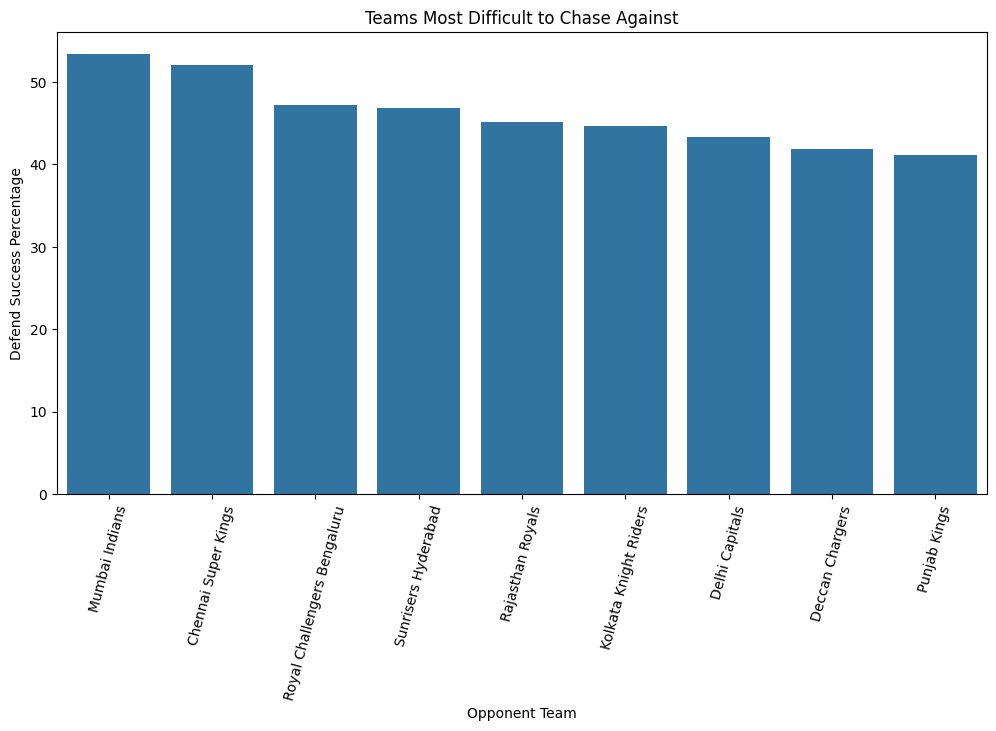

In [154]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=opponent_strength.index,
    y=opponent_strength.values
)

plt.title(
    "Teams Most Difficult to Chase Against"
)

plt.ylabel(
    "Defend Success Percentage"
)

plt.xlabel(
    "Opponent Team"
)

plt.xticks(rotation=75)

plt.show()

### The opponent-strength analysis highlights that IPL chase difficulty is heavily influenced by the quality and tactical discipline of the defending side. Teams such as Mumbai Indians and Chennai Super Kings emerge as the most difficult opponents to chase against, successfully defending targets in more than half of their matches.

Interestingly, many of the franchises identified as strong defending teams are also among the IPL’s most successful dynasties. This suggests that sustained tournament success is not driven solely by explosive batting, but by the ability to control pressure phases, restrict chasing momentum, and execute defensively under high-stakes conditions.

The analysis also reveals that chasing success in IPL cricket is highly contextual. A target that may appear manageable against one opponent can become significantly more

# MACHINE LEARNING MODEL 
## For predicting Successful Chase or Failed Chase

In [ ]:

# MACHINE LEARNING DATASET
# IPL LIVE CHASE PREDICTION




# FILTER INNINGS


innings1 = df[df['innings'] == 1].copy()

innings2 = df[df['innings'] == 2].copy()



# DEFENDING TEAM


defending_team = (

    innings1.groupby('match_id')
    ['batting_team']
    .first()
    .reset_index(name='defending_team')
)



# TARGET SCORE


target_score = (

    innings1.groupby('match_id')
    ['runs_total']
    .sum()
    .reset_index(name='target')
)

target_score['target'] += 1



# MERGE TARGET INTO INNINGS2


innings2 = innings2.merge(
    target_score,
    on='match_id'
)



# CURRENT SCORE


innings2['current_score'] = (

    innings2.groupby('match_id')
    ['runs_total']
    .cumsum()
)



# BALLS BOWLED


innings2['balls_bowled'] = (

    (innings2['over'] - 1) * 6

    +

    innings2['ball']
)



# BALLS REMAINING


innings2['balls_remaining'] = (

    120

    -

    innings2['balls_bowled']
)



# RUNS REMAINING


innings2['runs_remaining'] = (

    innings2['target']

    -

    innings2['current_score']
)



# WICKETS LOST


innings2['wicket'] = np.where(

    innings2['wicket_kind'].notna(),

    1,

    0
)

innings2['innings2_wickets'] = (

    innings2.groupby('match_id')
    ['wicket']
    .cumsum()
)



# WICKETS LEFT


innings2['wickets_left'] = (

    10

    -

    innings2['innings2_wickets']
)



# CURRENT RUN RATE


innings2['current_rr'] = (

    innings2['current_score']

    /

    (innings2['balls_bowled'] / 6)
)

innings2['current_rr'] = (

    innings2['current_rr']
    .replace([np.inf, -np.inf], 0)
)



# REQUIRED RUN RATE


innings2['required_rr'] = (

    innings2['runs_remaining'] * 6

    /

    innings2['balls_remaining']
)

innings2['required_rr'] = (

    innings2['required_rr']
    .replace([np.inf, -np.inf], 0)
)



# PRESSURE INDEX


innings2['pressure_index'] = (

    innings2['required_rr']

    -

    innings2['current_rr']
)



# STAR BATTERS


star_batters = [

    'Virat Kohli',
    'MS Dhoni',
    'Rohit Sharma',
    'David Warner',
    'KL Rahul',
    'AB de Villiers'
]

innings2['batter_category'] = np.where(

    innings2['batter'].isin(star_batters),

    innings2['batter'],

    'Others'
)



# STAR BOWLERS


star_bowlers = [

    'JJ Bumrah',
    'Rashid Khan',
    'SL Malinga',
    'YS Chahal',
    'DJ Bravo',
    'B Kumar'
]

innings2['bowler_category'] = np.where(

    innings2['bowler'].isin(star_bowlers),

    innings2['bowler'],

    'Others'
)



# FINAL MATCH STATE
# LAST BALL OF EACH MATCH

final_state = innings2.copy()


# FINAL DATAFRAME


final_df = (

    final_state

    .merge(
        defending_team,
        on='match_id'
    )
)



# RENAME CHASING TEAM


final_df = final_df.rename(
    columns={
        'batting_team': 'chasing_team'
    }
)



# WON TOSS


final_df['won_toss'] = np.where(

    final_df['chasing_team']

    ==

    final_df['toss_winner'],

    1,

    0
)



# TARGET VARIABLE


final_df['result'] = np.where(

    final_df['chasing_team']

    ==

    final_df['winner'],

    1,

    0
)



# REMOVE INVALID ROWS


final_df = final_df[

    final_df['balls_remaining'] > 0
]



# DROP LEAKAGE COLUMNS


final_df = final_df.drop(

    columns=[

        'winner',
        'batter',
        'bowler',
        'non_striker',
        'wicket',
        'wicket_kind',
        'wicket_player_out',
        'date',
        'season',
        'event',
        'city',
        'team1',
        'team2',
        'player_of_match',
        'win_by_runs',
        'win_by_wickets'
    ],

    errors='ignore'
)



# REMOVE MISSING VALUES


final_df = final_df.dropna()



# FEATURE COLUMNS


feature_cols = [

    'target',
    'current_score',
    'runs_remaining',
    'balls_remaining',
    'innings2_wickets',
    'wickets_left',
    'current_rr',
    'required_rr',
    'pressure_index',
    'won_toss',

    'chasing_team',
    'defending_team',
    'venue',
    'toss_decision',

    'batter_category',
    'bowler_category'
]



# INPUT + TARGET


X = final_df[feature_cols]

y = final_df['result']



# FINAL CHECK


print(final_df.shape)

final_df.head()

(139361, 32)


,match_id,venue,toss_winner,toss_decision,innings,chasing_team,over,ball,runs_batter,runs_extras,...,innings2_wickets,wickets_left,current_rr,required_rr,pressure_index,batter_category,bowler_category,defending_team,won_toss,result
0,1082591,"Rajiv Gandhi International Stadium, Uppal",Royal Challengers Bengaluru,field,2,Royal Challengers Bengaluru,0,1,1,0,...,0,10,-1.2,9.936000,11.136000,Others,Others,Sunrisers Hyderabad,1,0
1,1082591,"Rajiv Gandhi International Stadium, Uppal",Royal Challengers Bengaluru,field,2,Royal Challengers Bengaluru,0,2,0,0,...,0,10,-1.5,10.016129,11.516129,Others,Others,Sunrisers Hyderabad,1,0
2,1082591,"Rajiv Gandhi International Stadium, Uppal",Royal Challengers Bengaluru,field,2,Royal Challengers Bengaluru,0,3,0,0,...,0,10,-2.0,10.097561,12.097561,Others,Others,Sunrisers Hyderabad,1,0
3,1082591,"Rajiv Gandhi International Stadium, Uppal",Royal Challengers Bengaluru,field,2,Royal Challengers Bengaluru,0,4,2,0,...,0,10,-9.0,10.081967,19.081967,Others,Others,Sunrisers Hyderabad,1,0
4,1082591,"Rajiv Gandhi International Stadium, Uppal",Royal Challengers Bengaluru,field,2,Royal Challengers Bengaluru,0,5,4,0,...,0,10,-42.0,9.966942,51.966942,Others,Others,Sunrisers Hyderabad,1,0


In [156]:
final_df.head()

,match_id,venue,toss_winner,toss_decision,innings,chasing_team,over,ball,runs_batter,runs_extras,...,innings2_wickets,wickets_left,current_rr,required_rr,pressure_index,batter_category,bowler_category,defending_team,won_toss,result
0,1082591,"Rajiv Gandhi International Stadium, Uppal",Royal Challengers Bengaluru,field,2,Royal Challengers Bengaluru,0,1,1,0,...,0,10,-1.2,9.936000,11.136000,Others,Others,Sunrisers Hyderabad,1,0
1,1082591,"Rajiv Gandhi International Stadium, Uppal",Royal Challengers Bengaluru,field,2,Royal Challengers Bengaluru,0,2,0,0,...,0,10,-1.5,10.016129,11.516129,Others,Others,Sunrisers Hyderabad,1,0
2,1082591,"Rajiv Gandhi International Stadium, Uppal",Royal Challengers Bengaluru,field,2,Royal Challengers Bengaluru,0,3,0,0,...,0,10,-2.0,10.097561,12.097561,Others,Others,Sunrisers Hyderabad,1,0
3,1082591,"Rajiv Gandhi International Stadium, Uppal",Royal Challengers Bengaluru,field,2,Royal Challengers Bengaluru,0,4,2,0,...,0,10,-9.0,10.081967,19.081967,Others,Others,Sunrisers Hyderabad,1,0
4,1082591,"Rajiv Gandhi International Stadium, Uppal",Royal Challengers Bengaluru,field,2,Royal Challengers Bengaluru,0,5,4,0,...,0,10,-42.0,9.966942,51.966942,Others,Others,Sunrisers Hyderabad,1,0


In [157]:
final_df.info()

<class 'pandas.DataFrame'>
Index: 139361 entries, 0 to 139396
Data columns (total 32 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   match_id          139361 non-null  int64  
 1   venue             139361 non-null  str    
 2   toss_winner       139361 non-null  str    
 3   toss_decision     139361 non-null  str    
 4   innings           139361 non-null  int64  
 5   chasing_team      139361 non-null  str    
 6   over              139361 non-null  int64  
 7   ball              139361 non-null  int64  
 8   runs_batter       139361 non-null  int64  
 9   runs_extras       139361 non-null  int64  
 10  runs_total        139361 non-null  int64  
 11  extras_wides      139361 non-null  int64  
 12  extras_noballs    139361 non-null  int64  
 13  extras_byes       139361 non-null  int64  
 14  extras_legbyes    139361 non-null  int64  
 15  season_year       139361 non-null  int64  
 16  phase             139361 non-null  s

In [158]:
print(final_df.shape)

(139361, 32)


In [159]:
final_df.isnull().sum()

match_id            0
venue               0
toss_winner         0
toss_decision       0
innings             0
chasing_team        0
over                0
ball                0
runs_batter         0
runs_extras         0
runs_total          0
extras_wides        0
extras_noballs      0
extras_byes         0
extras_legbyes      0
season_year         0
phase               0
target              0
current_score       0
balls_bowled        0
balls_remaining     0
runs_remaining      0
innings2_wickets    0
wickets_left        0
current_rr          0
required_rr         0
pressure_index      0
batter_category     0
bowler_category     0
defending_team      0
won_toss            0
result              0
dtype: int64

In [160]:
print(
    final_df['result']
    .value_counts()
)

print(
    final_df['result']
    .value_counts(normalize=True) * 100
)

result
1    72061
0    67300
Name: count, dtype: int64
result
1    51.708154
0    48.291846
Name: proportion, dtype: float64


In [161]:

# TARGET CLASS PERCENTAGE


target_percent = (
    final_df['result']
    .value_counts(normalize=True)
    * 100
)

print(target_percent)

result
1    51.708154
0    48.291846
Name: proportion, dtype: float64


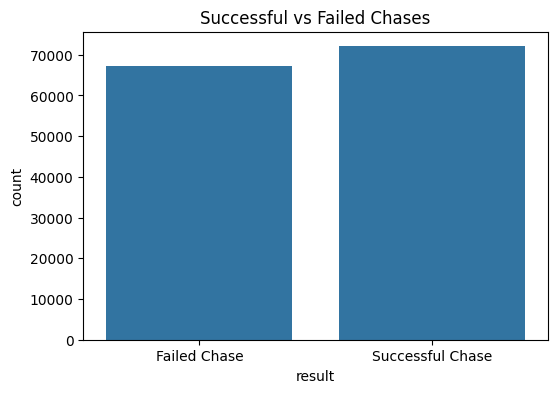

In [162]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='result',
    data=final_df
)

plt.title(
    "Successful vs Failed Chases"
)

plt.xticks(
    [0,1],
    ['Failed Chase', 'Successful Chase']
)

plt.show()

In [ ]:
from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (

    StandardScaler,
    OneHotEncoder
)

from sklearn.impute import SimpleImputer



# NUMERIC FEATURES
# LIVE MATCH FEATURES


numeric_features = [

    'target',

    'current_score',

    'runs_remaining',

    'balls_remaining',

    'innings2_wickets',

    'wickets_left',

    'current_rr',

    'required_rr',

    'pressure_index',

    'won_toss'
]



# CATEGORICAL FEATURES


categorical_features = [

    'chasing_team',

    'defending_team',

    'venue',

    'toss_decision',

    'batter_category',

    'bowler_category'
]



# NUMERIC TRANSFORMER


numeric_transformer = Pipeline([

    (

        'imputer',

        SimpleImputer(strategy='median')
    ),

    (

        'scaler',

        StandardScaler()
    )

])



# CATEGORICAL TRANSFORMER


categorical_transformer = Pipeline([

    (

        'imputer',

        SimpleImputer(strategy='most_frequent')
    ),

    (

        'encoder',

        OneHotEncoder(handle_unknown='ignore')
    )

])



# FINAL PREPROCESSOR


preprocessor = ColumnTransformer([

    (

        'num',

        numeric_transformer,

        numeric_features
    ),

    (

        'cat',

        categorical_transformer,

        categorical_features
    )

])


print("✅ Live Match Preprocessor created successfully!")

✅ Live Match Preprocessor created successfully!


In [164]:
X = final_df.drop(
    columns=[
        'match_id',
        'result'
    ]
)

In [165]:
y = final_df['result']

In [166]:
print(X.head())


                                       venue                  toss_winner  \
0  Rajiv Gandhi International Stadium, Uppal  Royal Challengers Bengaluru   
1  Rajiv Gandhi International Stadium, Uppal  Royal Challengers Bengaluru   
2  Rajiv Gandhi International Stadium, Uppal  Royal Challengers Bengaluru   
3  Rajiv Gandhi International Stadium, Uppal  Royal Challengers Bengaluru   
4  Rajiv Gandhi International Stadium, Uppal  Royal Challengers Bengaluru   

  toss_decision  innings                 chasing_team  over  ball  \
0         field        2  Royal Challengers Bengaluru     0     1   
1         field        2  Royal Challengers Bengaluru     0     2   
2         field        2  Royal Challengers Bengaluru     0     3   
3         field        2  Royal Challengers Bengaluru     0     4   
4         field        2  Royal Challengers Bengaluru     0     5   

   runs_batter  runs_extras  runs_total  ...  runs_remaining  \
0            1            0           1  ...             2

In [167]:
print(y.head())



0    0
1    0
2    0
3    0
4    0
Name: result, dtype: int64


In [168]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)


In [169]:
print("X_train shape :", X_train.shape)

X_train shape : (111488, 30)


In [170]:
print("X_test shape :", X_test.shape)

X_test shape : (27873, 30)


In [171]:
print("y_train shape :", y_train.shape)

y_train shape : (111488,)


In [172]:
print("y_test shape :", y_test.shape)

y_test shape : (27873,)


## LOGISTIC REGRESSION

In [173]:

# LOGISTIC REGRESSION MODEL


from sklearn.linear_model import LogisticRegression


# CREATE PIPELINE


log_model = Pipeline([

    (
        'preprocessor',
        preprocessor
    ),

    (
        'classifier',

        LogisticRegression(
            max_iter=1000
        )
    )

])


# TRAIN MODEL


log_model.fit(
    X_train,
    y_train
)


# PREDICTIONS


log_pred = log_model.predict(X_test)


# ACCURACY


from sklearn.metrics import accuracy_score

log_accuracy = accuracy_score(
    y_test,
    log_pred
)

print(
    "Logistic Regression Accuracy:",
    round(log_accuracy * 100, 2),
    "%"
)

Logistic Regression Accuracy: 80.96 %


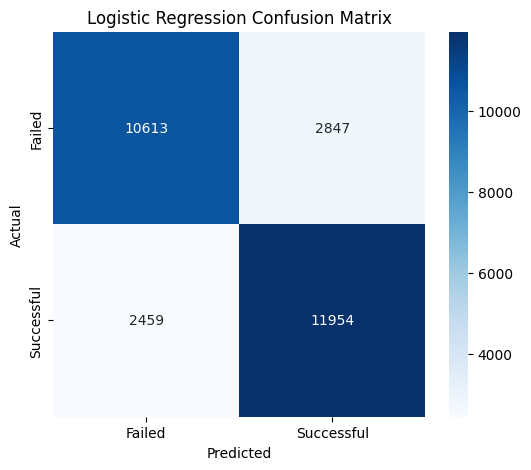

In [174]:

# LOGISTIC REGRESSION CONFUSION MATRIX


from sklearn.metrics import confusion_matrix

log_cm = confusion_matrix(
    y_test,
    log_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(

    log_cm,

    annot=True,

    fmt='d',

    cmap='Blues'
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.xticks(
    [0.5,1.5],
    ['Failed', 'Successful']
)

plt.yticks(
    [0.5,1.5],
    ['Failed', 'Successful']

)

plt.savefig(
    'images/confusion_matrix_lr.png',
    bbox_inches='tight'
)

plt.show()

In [175]:

# CLASSIFICATION REPORT


from sklearn.metrics import classification_report

print(

    classification_report(
        y_test,
        log_pred
    )

)

              precision    recall  f1-score   support

           0       0.81      0.79      0.80     13460
           1       0.81      0.83      0.82     14413

    accuracy                           0.81     27873
   macro avg       0.81      0.81      0.81     27873
weighted avg       0.81      0.81      0.81     27873



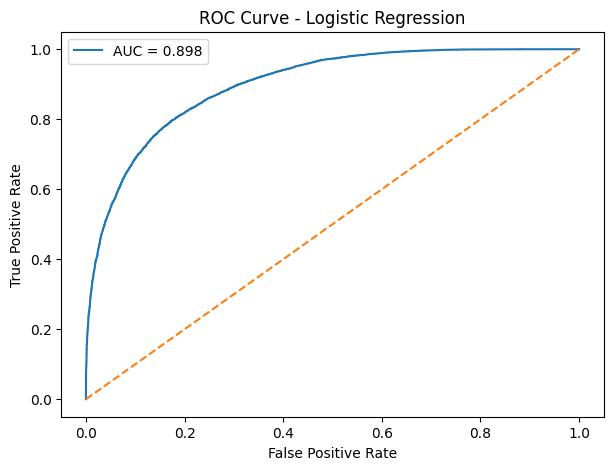

In [176]:

# ROC CURVE


from sklearn.metrics import (
    roc_curve,
    auc
)

# Prediction probabilities

log_probs = (
    log_model.predict_proba(X_test)
    [:,1]
)

# ROC values

fpr, tpr, thresholds = roc_curve(
    y_test,
    log_probs
)

roc_auc = auc(
    fpr,
    tpr
)

# Plot

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {roc_auc:.3f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.title(
    "ROC Curve - Logistic Regression"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

# Logistic Regression Model Insights


Logistic Regression was used as the first baseline model for IPL chase prediction. Since it is a simple linear model, its performance helps answer an important question: are IPL chase outcomes completely chaotic, or do they follow measurable tactical patterns?

The model achieved an accuracy of **80.96%**, which is a strong baseline result. This shows that even without complex tree-based learning, the engineered match features are already capturing meaningful chase signals such as target pressure, required run rate, wickets remaining, current score, and innings situation.

## Confusion Matrix Insights

The confusion matrix shows that the model performs in a fairly balanced way across both failed and successful chases.

The model correctly identified:

- **10,613 failed chase situations**
- **11,954 successful chase situations**

It made:

- **2,847 false successful predictions**
- **2,459 false failed predictions**

This means the model is slightly better at recognizing successful chase patterns than failed ones. That is interesting from a cricket intelligence perspective because successful chases often follow a more structured pattern: controlled scoring, enough wickets in hand, and manageable required run rate.

Failed chases, however, can happen in more unpredictable ways. A team may collapse suddenly, fall behind the required rate, or lose momentum despite being in a decent position earlier. This makes failed chase situations slightly harder for a linear model to separate perfectly.

## Classification Report Interpretation

The classification report confirms this balanced performance:

- Failed chases: **precision 0.81, recall 0.79, F1-score 0.80**
- Successful chases: **precision 0.81, recall 0.83, F1-score 0.82**
- Overall accuracy: **0.81**

The recall for successful chases is slightly higher, meaning the model is better at identifying actual successful chases. This supports the idea that successful IPL chases leave clearer statistical fingerprints: stable scoring rate, lower wicket loss, and controlled pressure.

At the same time, the model does not heavily favor one class over the other. Both failed and successful chases are predicted with similar precision, which makes Logistic Regression a reliable baseline model for comparison with Random Forest and XGBoost.

## ROC Curve & AUC Analysis

The Logistic Regression model achieved an AUC score of **0.898**.

This is a strong result because an AUC close to 0.90 means the model has good ability to separate successful chases from failed chases across different probability thresholds.

However, it is not a near-perfect model. Instead, it suggests that IPL chase prediction is partly structured and partly uncertain. The model captures major tactical signals, but cricket still contains sudden shifts caused by wickets, pressure, matchups, and death-over execution.

## Strategic Cricket Intelligence Insight

The most important insight from Logistic Regression is that IPL chase outcomes are not random. Even a simple interpretable model can predict results with around 81% accuracy, meaning the match situation carries strong tactical information.

The model suggests that chase success is strongly linked with:

- preserving wickets
- keeping the required run rate under control
- building stable scoring momentum
- avoiding pressure spikes
- maintaining enough resources for the final overs

This connects well with the earlier EDA findings, especially the analysis around middle-over control, wicket impact, and pressure dynamics.

## Why This Model Matters

Logistic Regression is important because it gives a clear and interpretable benchmark. It suggests that the feature engineering is meaningful before moving to more complex models.

The model does not claim IPL chases are perfectly predictable. Instead, it shows something more realistic and more interesting: successful chases usually follow a recognizable tactical structure, while failed chases are more volatile and harder to classify.

So, Logistic Regression becomes the foundation of the machine learning story. It shows that the project is not just predicting outcomes, but learning the cricket logic behind those outcomes.

In [177]:

# IMPORT MODEL


from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline


# CREATE MODEL PIPELINE


model = Pipeline([

    (
        'preprocessor',
        preprocessor
    ),

    (
        'classifier',

        RandomForestClassifier(

            n_estimators=200,

            max_depth=10,

            random_state=42
        )
    )

])


# TRAIN MODEL


model.fit(
    X_train,
    y_train
)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [178]:

# MAKE PREDICTIONS


y_pred = model.predict(X_test)

print(y_pred[:10])

[0 1 0 1 1 1 0 0 1 0]


In [179]:

# ACCURACY SCORE


from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Model Accuracy:",
    round(accuracy * 100, 2),
    "%"
)

Model Accuracy: 83.25 %


In [180]:

# CLASSIFICATION REPORT


from sklearn.metrics import classification_report

print(

    classification_report(
        y_test,
        y_pred
    )

)

              precision    recall  f1-score   support

           0       0.84      0.80      0.82     13460
           1       0.82      0.86      0.84     14413

    accuracy                           0.83     27873
   macro avg       0.83      0.83      0.83     27873
weighted avg       0.83      0.83      0.83     27873



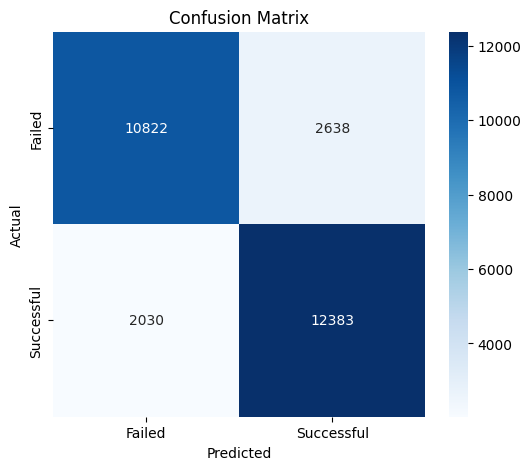

In [181]:

# CONFUSION MATRIX


from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    "Confusion Matrix"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.xticks(
    [0.5,1.5],
    ['Failed', 'Successful']
)

plt.yticks(
    [0.5,1.5],
    ['Failed', 'Successful']
)

plt.savefig(
    'images/confusion_matrix_rf.png',
    bbox_inches='tight'
)

plt.show()

## Random forest model

In [182]:

# EXTRACT RANDOM FOREST MODEL


rf_model = model.named_steps['classifier']

# 
# GET FEATURE NAMES


encoded_features = model.named_steps[
    'preprocessor'
].get_feature_names_out()


# FEATURE IMPORTANCE

importance_df = pd.DataFrame({

    'feature': encoded_features,

    'importance': rf_model.feature_importances_

})

# SORT FEATURES


importance_df = (
    importance_df.sort_values(
        by='importance',
        ascending=False
    )
)


# TOP 15 FEATURES


top_features = importance_df.head(15)

print(top_features)

                                       feature  importance
7                             num__required_rr    0.273878
8                          num__pressure_index    0.173808
0                                  num__target    0.132883
4                        num__innings2_wickets    0.079107
5                            num__wickets_left    0.075060
2                          num__runs_remaining    0.067476
6                              num__current_rr    0.031333
3                         num__balls_remaining    0.020897
1                           num__current_score    0.018056
19             cat__chasing_team_Pune Warriors    0.006932
67  cat__venue_MA Chidambaram Stadium, Chepauk    0.005863
28           cat__defending_team_Gujarat Lions    0.003935
35            cat__defending_team_Punjab Kings    0.003774
99                      cat__toss_decision_bat    0.003700
10       cat__chasing_team_Chennai Super Kings    0.003629


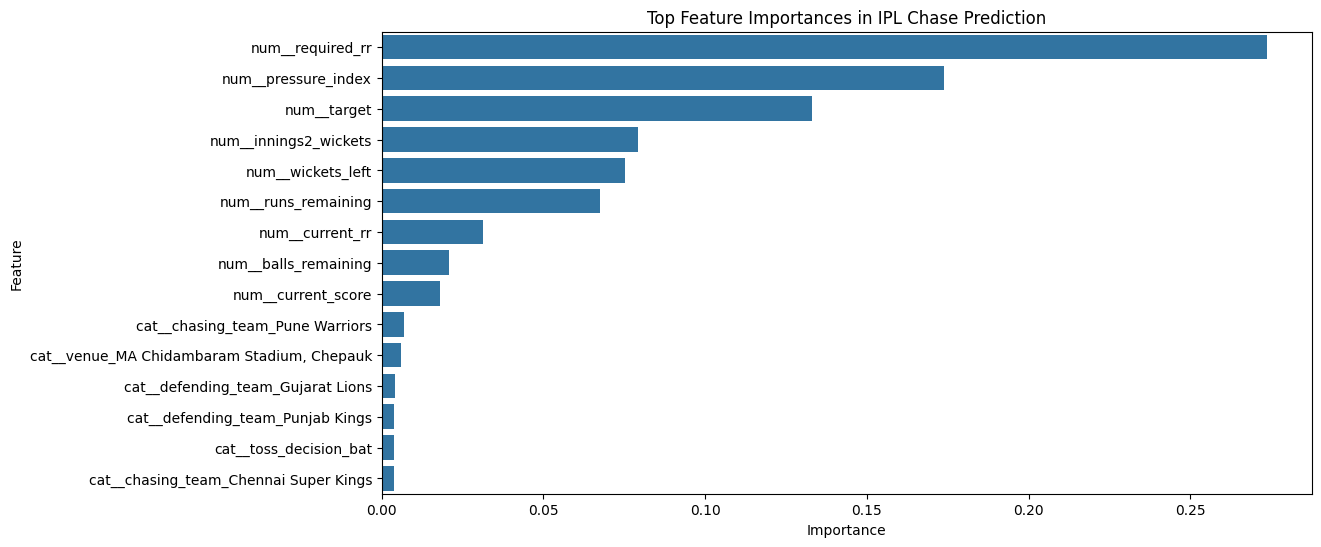

In [183]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_features,
    x='importance',
    y='feature'
)

plt.title(
    "Top Feature Importances in IPL Chase Prediction"
)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.savefig(
    'images/feature_importance.png',
    bbox_inches='tight'
)

plt.show()

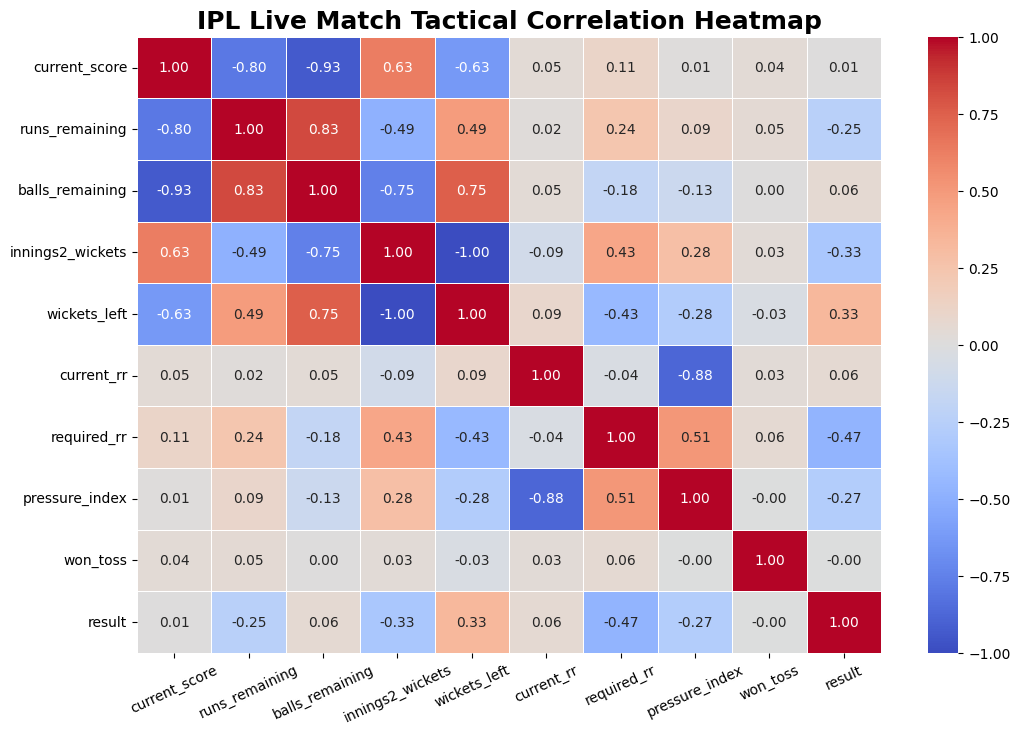

In [184]:
# ==========================================
# CLEAN CORRELATION HEATMAP
# ==========================================

important_corr = final_df[

    [

        'current_score',

        'runs_remaining',

        'balls_remaining',

        'innings2_wickets',

        'wickets_left',

        'current_rr',

        'required_rr',

        'pressure_index',

        'won_toss',

        'result'
    ]
]


plt.figure(figsize=(12,8))

sns.heatmap(

    important_corr.corr(),

    annot=True,

    cmap='coolwarm',

    fmt=".2f",

    linewidths=0.5
)

plt.title(

    "IPL Live Match Tactical Correlation Heatmap",

    fontsize=18,

    fontweight='bold'
)

plt.xticks(rotation=25)

plt.yticks(rotation=0)

plt.savefig(

    'images/correlation_heatmap.png',

    bbox_inches='tight'
)

plt.show()

Random Forest AUC: 0.922


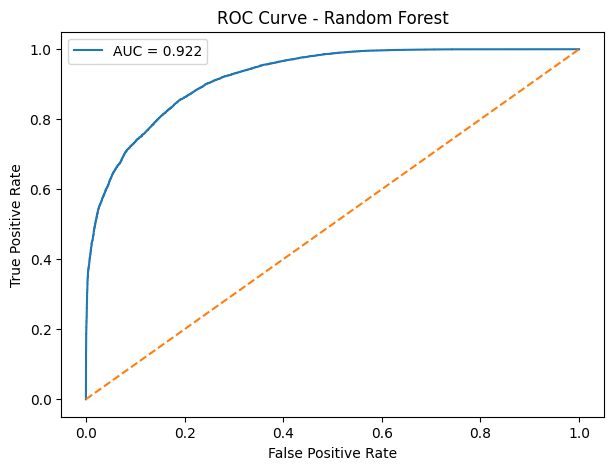

In [185]:

# RANDOM FOREST ROC CURVE


from sklearn.metrics import (
    roc_curve,
    auc
)


# PREDICTION PROBABILITIES


rf_probs = (
    model.predict_proba(X_test)
    [:,1]
)


# ROC VALUES


rf_fpr, rf_tpr, rf_thresholds = roc_curve(

    y_test,

    rf_probs
)


# AUC SCORE


rf_auc = auc(
    rf_fpr,
    rf_tpr
)

print(
    "Random Forest AUC:",
    round(rf_auc, 3)
)


# PLOT ROC CURVE


plt.figure(figsize=(7,5))

plt.plot(

    rf_fpr,

    rf_tpr,

    label=f'AUC = {rf_auc:.3f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.title(
    "ROC Curve - Random Forest"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.legend()

plt.show()

## Random Forest Model Insights

Random Forest was used as the second machine learning model to capture more complex IPL chase patterns. Unlike Logistic Regression, which learns mostly linear relationships, Random Forest can understand nonlinear combinations between features such as required run rate, wickets, pressure index, target score, and balls remaining.

The model achieved an accuracy of **83.25%** with an AUC score of **0.922**. This is an improvement over Logistic Regression, showing that IPL chase outcomes are not only shaped by direct relationships, but also by interactions between match situations.

## Confusion Matrix Insights

The Random Forest model correctly identified:

- **10,822 failed chase situations**
- **12,383 successful chase situations**

It made:

- **2,638 false successful predictions**
- **2,030 false failed predictions**

This shows that Random Forest is slightly better at detecting successful chases than failed ones. The model identifies chase success well when teams have strong tactical indicators such as enough wickets left, manageable required run rate, and stable scoring momentum.

Compared with Logistic Regression, Random Forest reduces missed successful chases and captures more match context. This suggests that chase success is not decided by one factor alone, but by combinations of pressure, wickets, target size, and scoring rate.

## Classification Report Interpretation

The classification report shows:

- Failed chases: **precision 0.84, recall 0.80, F1-score 0.82**
- Successful chases: **precision 0.82, recall 0.86, F1-score 0.84**
- Overall accuracy: **0.83**

The higher recall for successful chases means the model is strong at recognizing when a chase is likely to succeed. This supports the cricket idea that successful chases usually have clearer tactical structure, while failed chases can happen through more sudden collapses or pressure shifts.

## Feature Importance Insights

The most important features identified by Random Forest were:

- **required run rate**
- **pressure index**
- **target**
- **innings2 wickets**
- **wickets left**
- **runs remaining**

This is one of the strongest findings in the project. The model is not relying mainly on team names or venues. Instead, it is focusing on live match pressure and chase resources.

The dominance of required run rate and pressure index shows that scoreboard pressure is the central driver of chase prediction. Wickets also play a major role because they determine how much risk a batting team can take while chasing.

This connects strongly with the earlier EDA sections: middle-over control, wicket preservation, and pressure management are not just observations, but machine-learned predictors of chase outcome.

## ROC Curve & AUC Analysis

The Random Forest model achieved an AUC score of **0.922**, which indicates strong class separation between successful and failed chases.

This means the model is not only making good final predictions, but also assigning useful probability scores. It can separate strong chase situations from risky ones more clearly than Logistic Regression.

## Tactical Cricket Intelligence Insight

Random Forest acts like the cricket intelligence layer of the project. It shows that IPL chase success depends on combinations of match conditions rather than single isolated factors.

For example, a high required run rate is dangerous, but it becomes even more dangerous when wickets are low. A large target is difficult, but it can still be chased if the current run rate is strong and enough balls remain.

This makes Random Forest valuable because it captures the layered nature of T20 cricket: pressure, wickets, scoring rate, and target size interact together.

## XGBOOST

In [186]:
from xgboost import XGBClassifier

In [ ]:

# XGBOOST MODEL


xgb_model = Pipeline([

    (
        'preprocessor',
        preprocessor
    ),

    (
        'classifier',

        XGBClassifier(

            n_estimators=200,

            learning_rate=0.05,

            max_depth=6,

            random_state=42,

            eval_metric='logloss'
        )
    )

])


# TRAIN MODEL


xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [188]:

# PREDICTIONS


xgb_pred = xgb_model.predict(X_test)

In [189]:

# ACCURACY


xgb_accuracy = accuracy_score(
    y_test,
    xgb_pred
)

print(
    "XGBoost Accuracy:",
    round(xgb_accuracy * 100, 2),
    "%"
)

XGBoost Accuracy: 90.35 %


In [190]:

# XGBOOST CLASSIFICATION REPORT


print(

    classification_report(
        y_test,
        xgb_pred
    )

)

              precision    recall  f1-score   support

           0       0.92      0.88      0.90     13460
           1       0.89      0.93      0.91     14413

    accuracy                           0.90     27873
   macro avg       0.90      0.90      0.90     27873
weighted avg       0.90      0.90      0.90     27873



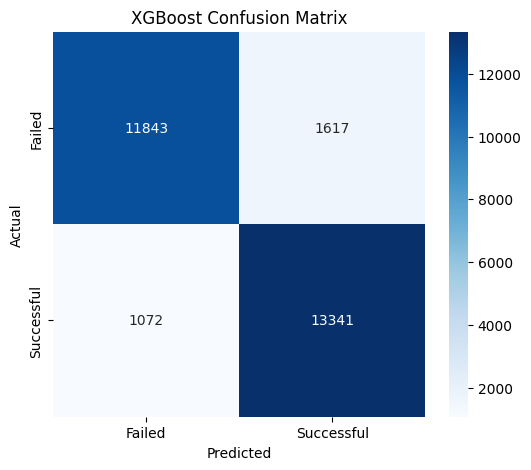

In [191]:

# XGBOOST CONFUSION MATRIX


from sklearn.metrics import confusion_matrix

xgb_cm = confusion_matrix(
    y_test,
    xgb_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(

    xgb_cm,

    annot=True,

    fmt='d',

    cmap='Blues'
)

plt.title(
    "XGBoost Confusion Matrix"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.xticks(
    [0.5,1.5],
    ['Failed', 'Successful']
)

plt.yticks(
    [0.5,1.5],
    ['Failed', 'Successful']
)

plt.savefig(
    'images/confusion_matrix_xgb.png',
    bbox_inches='tight'
)
plt.show()

XGBoost AUC: 0.97


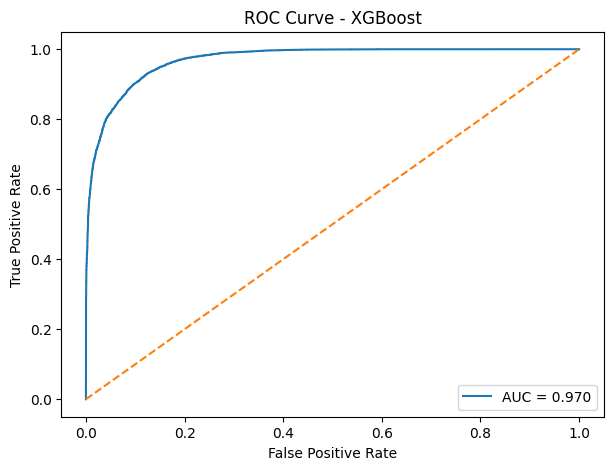

In [192]:

# XGBOOST ROC CURVE


xgb_probs = (
    xgb_model.predict_proba(X_test)
    [:,1]
)

xgb_fpr, xgb_tpr, _ = roc_curve(
    y_test,
    xgb_probs
)

xgb_auc = auc(
    xgb_fpr,
    xgb_tpr
)

print(
    "XGBoost AUC:",
    round(xgb_auc, 3)
)


# PLOT ROC CURVE


plt.figure(figsize=(7,5))

plt.plot(

    xgb_fpr,

    xgb_tpr,

    label=f'AUC = {xgb_auc:.3f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.title(
    "ROC Curve - XGBoost"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

## XGBoost Model Insights

XGBoost was the strongest predictive model in the project. It achieved an accuracy of **90.35%** and an AUC score of **0.970**, making it the best-performing model among Logistic Regression, Random Forest, and XGBoost.

This result shows that IPL chase outcomes contain complex patterns that boosting models can capture very effectively. XGBoost learns step by step, correcting earlier mistakes and focusing more strongly on difficult chase situations.

## Confusion Matrix Insights

The XGBoost model correctly identified:

- **11,843 failed chase situations**
- **13,341 successful chase situations**

It made:

- **1,617 false successful predictions**
- **1,072 false failed predictions**

This is a major improvement over both Logistic Regression and Random Forest. The model reduced errors on both sides, meaning it became better at recognizing not only successful chases, but also failed chase situations.

This is especially important because failed chases are often harder to predict. They can result from sudden wickets, pressure spikes, slowing run rate, or collapse in momentum. XGBoost handled these unstable situations better than the previous models.

## Classification Report Interpretation

The classification report shows:

- Failed chases: **precision 0.92, recall 0.88, F1-score 0.90**
- Successful chases: **precision 0.89, recall 0.93, F1-score 0.91**
- Overall accuracy: **0.90**

The model performs strongly for both classes, but its recall for successful chases is especially high at **0.93**. This means XGBoost correctly identifies most actual successful chases.

At the same time, the failed-chase precision of **0.92** is very strong, meaning when the model predicts a failed chase, it is usually correct. This makes XGBoost the most reliable model for high-confidence chase prediction.

## ROC Curve & AUC Analysis

XGBoost achieved an AUC score of **0.970**, which is excellent.

This means the model is very strong at separating successful and failed chase situations across different probability thresholds. The ROC curve shows that XGBoost has the clearest separation between the two outcomes compared with the other models.

In practical cricket terms, this means XGBoost is very good at reading the state of a chase and identifying whether the batting team is in control or under serious pressure.

## Strategic Cricket Intelligence Insight

The main insight from XGBoost is that IPL chase prediction improves when the model can learn complex pressure transitions.

A chase does not fail only because the target is high. It may fail because the required run rate rises while wickets fall, balls run out, and pressure increases together. XGBoost is powerful because it captures these combined effects.

The model likely learns patterns such as:

- high required run rate with low wickets left
- rising pressure index during middle overs
- large target with poor current run rate
- fewer balls remaining with high runs required
- chase stability when wickets are preserved

This makes XGBoost the most complete predictive model in the notebook.

## Why XGBoost Performed Best

XGBoost outperformed Logistic Regression and Random Forest because it combines multiple strengths:

- it captures nonlinear patterns
- it learns from previous mistakes
- it handles complex feature interactions
- it separates successful and failed chases more clearly
- it performs strongly on both accuracy and AUC

The jump from Logistic Regression accuracy **80.96%** to XGBoost accuracy **90.35%** shows that IPL chase outcomes are not purely linear. There are deeper tactical interactions in the data, especially around pressure, wickets, and scoring momentum.

## Final XGBoost Takeaway

XGBoost is the best final prediction model for this project.

It does not just predict better; it also supports the broader storyline of the notebook: IPL chases are shaped by pressure management, wicket preservation, required run rate control, and momentum stability.

The model confirms that successful chases usually follow a strong tactical structure, while failed chases become detectable when pressure indicators start moving against the batting team.




## Comparative Analysis of Machine Learning Models

In [193]:

# MODEL COMPARISON TABLE


comparison_df = pd.DataFrame({

    'Model': [

        'Logistic Regression',

        'Random Forest',

        'XGBoost'
    ],

    'Accuracy': [

        round(log_accuracy * 100, 2),

        round(accuracy * 100, 2),

        round(xgb_accuracy * 100, 2)
    ],

    'AUC Score': [

        round(roc_auc, 3),

        round(rf_auc, 3),

        round(xgb_auc, 3)
    ]

})

print(comparison_df)

                 Model  Accuracy  AUC Score
0  Logistic Regression     80.96      0.898
1        Random Forest     83.25      0.922
2              XGBoost     90.35      0.970


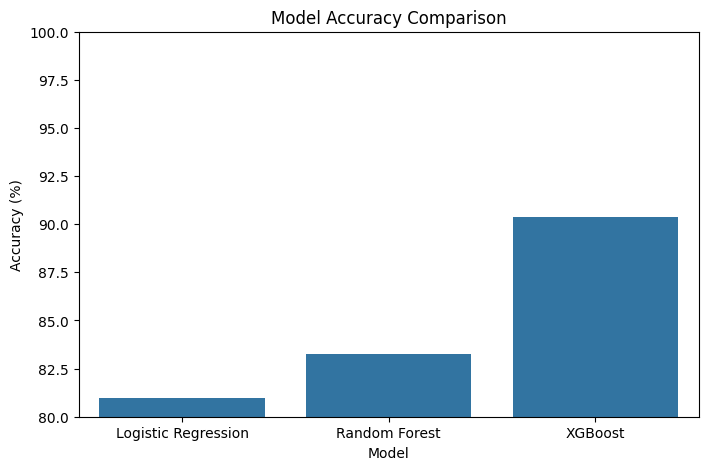

In [194]:

# MODEL ACCURACY COMPARISON


plt.figure(figsize=(8,5))

sns.barplot(

    data=comparison_df,

    x='Model',

    y='Accuracy'
)

plt.title(
    "Model Accuracy Comparison"
)

plt.ylabel(
    "Accuracy (%)"
)

plt.ylim(80,100)

plt.savefig(
    'images/model_accuracy_comparison.png',
    bbox_inches='tight'
)
plt.show()

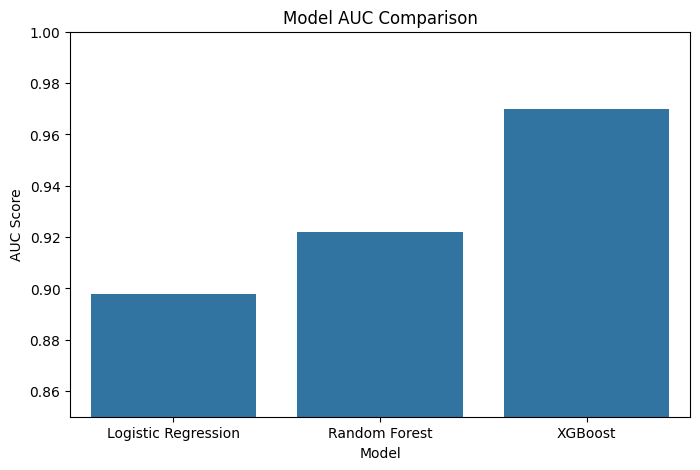

In [195]:

# MODEL AUC COMPARISON


plt.figure(figsize=(8,5))

sns.barplot(

    data=comparison_df,

    x='Model',

    y='AUC Score'
)

plt.title(
    "Model AUC Comparison"
)

plt.ylabel(
    "AUC Score"
)

plt.ylim(0.85,1.0)

plt.show()

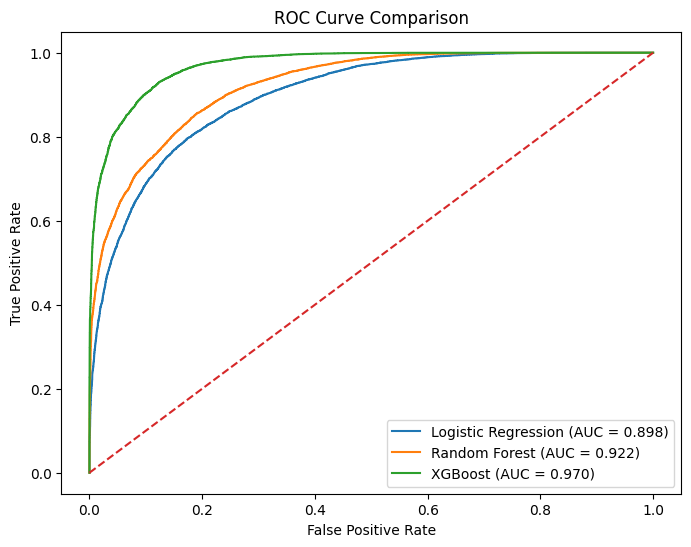

In [196]:

# COMBINED ROC CURVES


plt.figure(figsize=(8,6))

# Logistic Regression

plt.plot(

    fpr,

    tpr,

    label=f'Logistic Regression (AUC = {roc_auc:.3f})'
)

# Random Forest

plt.plot(

    rf_fpr,

    rf_tpr,

    label=f'Random Forest (AUC = {rf_auc:.3f})'
)

# XGBoost

plt.plot(

    xgb_fpr,

    xgb_tpr,

    label=f'XGBoost (AUC = {xgb_auc:.3f})'
)

# Random line

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.title(
    "ROC Curve Comparison"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.legend()

plt.savefig(
    'images/roc_curve_comparison.png',
    bbox_inches='tight'
)

plt.show()

### To evaluate how different machine learning approaches interpret IPL chase dynamics, three fundamentally different predictive models were implemented and analyzed:

- Logistic Regression
- Random Forest
- XGBoost

Each model offered a different level of understanding. Logistic Regression acted as the interpretable baseline, Random Forest captured tactical interactions between match features, and XGBoost delivered the strongest predictive performance.

The comparison was based on two major evaluation metrics:

- **Accuracy**, to measure overall prediction correctness
- **AUC Score**, to measure how well each model separates successful and failed chases

## Model Performance Comparison

The results showed a clear improvement as model complexity increased:

| Model | Accuracy | AUC Score |
|---|---:|---:|
| Logistic Regression | 80.96% | 0.898 |
| Random Forest | 83.25% | 0.922 |
| XGBoost | 90.35% | 0.970 |

Logistic Regression achieved a strong baseline accuracy of **80.96%**, proving that IPL chase outcomes contain structured patterns that can be captured through engineered match features.

Random Forest improved the performance to **83.25%**, showing that nonlinear relationships between pressure, wickets, target score, and run rate provide additional predictive value.

XGBoost produced the best result with **90.35% accuracy** and an AUC score of **0.970**, making it the strongest model for final chase prediction.

## Logistic Regression — The Baseline Model

Logistic Regression showed that IPL chase outcomes are not random. Even a simple linear model was able to predict results with around **81% accuracy**.

This means the engineered features such as required run rate, wickets left, pressure index, target, and current score already contain strong predictive information.

However, Logistic Regression has limitations. Since it mainly captures linear relationships, it cannot fully model complex cricket situations where multiple factors interact together, such as high required run rate combined with low wickets and fewer balls remaining.

## Random Forest — The Tactical Interaction Model

Random Forest improved on Logistic Regression by capturing nonlinear relationships and feature interactions.

Its accuracy of **83.25%** and AUC score of **0.922** show that chase prediction improves when the model can understand combinations of match conditions.

The feature importance graph made Random Forest especially valuable. It showed that the most important predictors were:

- required run rate
- pressure index
- target
- innings2 wickets
- wickets left
- runs remaining

This confirmed that the model was learning real cricket logic rather than depending mainly on team names or venue effects.

Random Forest therefore became the most useful model for tactical interpretation.

## XGBoost — The Strongest Predictive Model

XGBoost was the best-performing model in the comparison.

It achieved:

- **90.35% accuracy**
- **0.970 AUC score**

This shows that boosting was highly effective for IPL chase prediction. XGBoost learns sequentially, correcting earlier mistakes and focusing more on difficult cases.

Its strong performance suggests that IPL chase outcomes are influenced by complex pressure transitions. A chase situation may change quickly when required run rate rises, wickets fall, and balls remaining decrease together.

XGBoost captured these combined effects better than the other models.

## Overall Model Comparison Insight

The model comparison reveals a clear storyline.

Logistic Regression proved that chase outcomes have a strong basic structure. Random Forest showed that tactical interactions between match features improve prediction. XGBoost then captured the deepest pressure and momentum patterns, making it the best final model.

The performance progression:

**80.96% → 83.25% → 90.35%**

shows that model complexity added real value in this project.

At the same time, all three models supported the same cricket conclusion: IPL chase success depends heavily on scoreboard pressure, wickets in hand, required run rate control, and momentum stability.

## Final Strategic Conclusion

The comparison confirms that IPL chase prediction is not just about choosing the most complex model. It is about combining strong feature engineering with the right algorithm.

In this project:

- Logistic Regression provided interpretability
- Random Forest explained tactical feature importance
- XGBoost delivered the strongest predictive accuracy

Together, the models made the notebook more complete than a basic prediction task, because they helped explain the cricket logic behind the result.

The final takeaway is that successful IPL chases are not only luck-based. They follow measurable patterns, and machine learning can detect many of those patterns through pressure, wickets, scoring rate, and chase momentum.

# FEATURE IMPORTANCE GRAPH



## Hyperparameter tuning with RandomizedSearchCV

In [197]:
from sklearn.model_selection import RandomizedSearchCV

In [198]:

# RANDOM FOREST PARAMETER GRID


param_grid = {

    'classifier__n_estimators': [
        100,
        200,
        300
    ],

    'classifier__max_depth': [
        5,
        10,
        15,
        None
    ],

    'classifier__min_samples_split': [
        2,
        5,
        10
    ],

    'classifier__min_samples_leaf': [
        1,
        2,
        4
    ]
}

In [199]:
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=3,
    cv=2,
    scoring='accuracy',
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)


Fitting 2 folds for each of 3 candidates, totalling 6 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__max_depth': [5, 10, ...], 'classifier__min_samples_leaf': [1, 2, ...], 'classifier__min_samples_split': [2, 5, ...], 'classifier__n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",3
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-

In [200]:

# BEST PARAMETERS


print(
    random_search.best_params_
)

{'classifier__n_estimators': 300, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 4, 'classifier__max_depth': 15}


In [201]:

# BEST CROSS VALIDATION SCORE


print(

    "Best CV Score:",

    round(
        random_search.best_score_ * 100,
        2
    ),

    "%"
)

Best CV Score: 87.98 %


In [202]:

# BEST MODEL


best_rf = random_search.best_estimator_

In [203]:

# PREDICTIONS


best_pred = best_rf.predict(
    X_test
)


# ACCURACY


best_accuracy = accuracy_score(
    y_test,
    best_pred
)

print(

    "Tuned Random Forest Accuracy:",

    round(best_accuracy * 100, 2),

    "%"
)

Tuned Random Forest Accuracy: 89.42 %


### Hyperparameter Tuning with RandomizedSearchCV

After building the initial Random Forest model, hyperparameter tuning was performed using `RandomizedSearchCV` to improve model performance and find a better combination of tree-based parameters.

The tuning process tested different values for:

- number of trees
- maximum tree depth
- minimum samples required to split a node
- minimum samples required at a leaf node

Instead of checking every possible combination, `RandomizedSearchCV` randomly selected a smaller set of parameter combinations. This made the tuning process faster while still giving the model a chance to improve.

## Best Parameters Found

The best parameter combination was:

```python
{
    'classifier__n_estimators': 300,
    'classifier__min_samples_split': 5,
    'classifier__min_samples_leaf': 4,
    'classifier__max_depth': 15
}

In [204]:
import shap

c:\Users\Hare kant jha\OneDrive\Desktop\IPL-Match-Intelligence\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [205]:

# TRANSFORM DATA


X_train_processed = (
    preprocessor.fit_transform(X_train)
)

X_test_processed = (
    preprocessor.transform(X_test)
)


# CONVERT TO DENSE ARRAY


X_train_processed = (
    X_train_processed.toarray()
)

X_test_processed = (
    X_test_processed.toarray()
)

In [206]:

# EXTRACT TUNED RANDOM FOREST


rf_explainer_model = (
    best_rf.named_steps['classifier']
)

In [ ]:


# CREATE SHAP EXPLAINER


explainer = shap.TreeExplainer(
    rf_explainer_model
)



# SAMPLE DATA


X_sample = X_test_processed[:500]



# CREATE SHAP VALUES


shap_values = explainer(
    X_sample
)



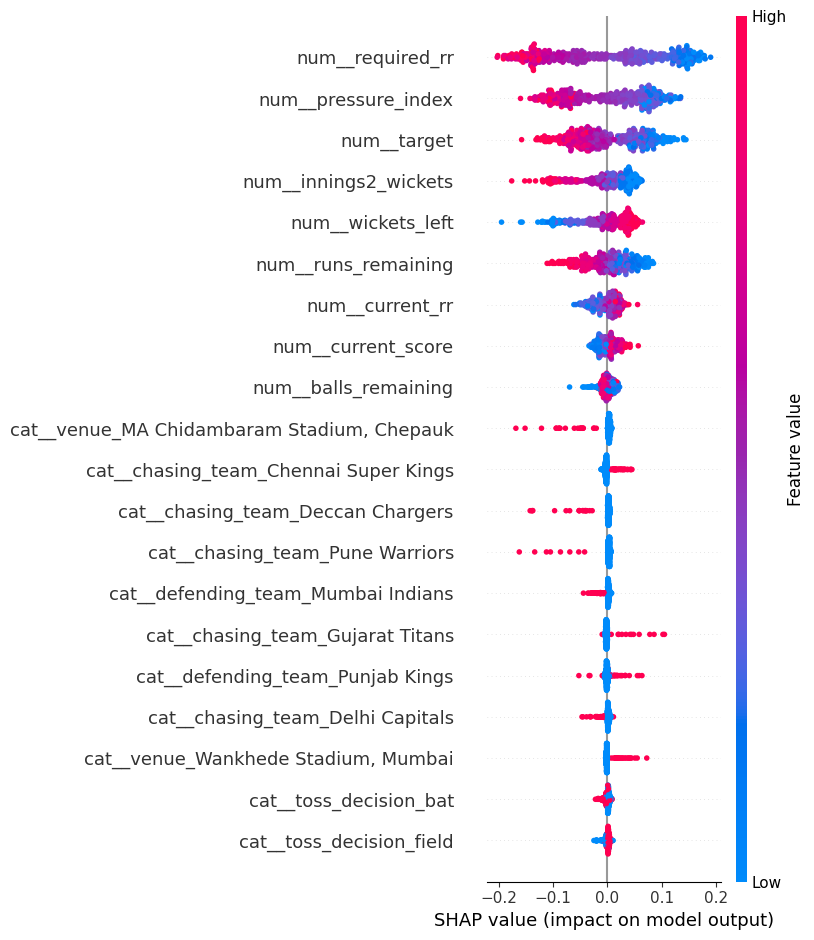

In [ ]:

# GET FEATURE NAMES


feature_names = (

    preprocessor
    .get_feature_names_out()
)



# SHAP SUMMARY PLOT


shap.summary_plot(

    shap_values.values[:, :, 1],

    X_sample,

    feature_names=feature_names,

    show=False
)

plt.savefig(

    'images/summary_plot.png',

    bbox_inches='tight'
)

plt.show()

## SHAP Explainability Insights: Decoding IPL Chase Intelligence

SHAP was used to explain how the tuned Random Forest model makes chase predictions. Unlike accuracy or feature importance, SHAP does not only show which features matter. It shows whether each feature pushes the model toward a successful chase or a failed chase.

In this SHAP plot, positive SHAP values push the prediction toward **successful chase**, while negative SHAP values push the prediction toward **failed chase**.

## Required Run Rate Is the Strongest Pressure Signal

The most influential feature in the SHAP summary plot is **required run rate**.

High required run rate values strongly push predictions toward failed chases, while lower required run rate values push predictions toward successful chases.

This is one of the clearest cricket insights in the model. A chase becomes dangerous when the batting team is forced to score faster than its current momentum allows. As the required rate increases, shot selection becomes riskier, wicket probability rises, and the chase starts moving toward collapse.

## Pressure Index Captures the Match Situation

The second most important SHAP feature is **pressure index**.

High pressure index values mostly push the model toward failed chases. This confirms that pressure is not just a psychological concept in cricket; it is measurable through match conditions such as required rate, balls remaining, runs remaining, and wickets in hand.

This supports the broader storyline of the project: IPL chases are often decided by how well teams manage pressure before it becomes uncontrollable.

## Target Score Still Matters

The SHAP plot also shows that **target** has a strong effect on predictions.

Higher targets generally push the model toward failed chases, while lower targets make successful chases more likely. This aligns with the earlier winning-score threshold analysis, where larger first-innings totals created stronger scoreboard pressure.

However, target is not acting alone. A high target can still be chased if wickets are preserved and the required run rate remains manageable.

## Wickets Decide Chase Stability

The features **innings2 wickets** and **wickets left** both play major roles.

Higher wicket loss pushes predictions toward failed chases, while more wickets remaining pushes predictions toward successful chases.

This is a very important tactical insight. Wickets are not just dismissals; they represent batting resources. A team with wickets in hand can take calculated risks, accelerate later, and survive pressure phases. A team with fewer wickets has less freedom and becomes more vulnerable to collapse.

## Runs Remaining, Current Run Rate, and Current Score

Features such as **runs remaining**, **current run rate**, and **current score** also influence predictions, but slightly less than required run rate, pressure index, and wickets.

This suggests that the model is not simply asking, “How many runs are left?” It is asking a more tactical question:

Can the batting team realistically chase these runs with the balls, wickets, and scoring rate available?

That makes the model more cricket-intelligent than a simple scoreboard-based predictor.

## Team, Venue, and Toss Effects Are Smaller

The lower part of the SHAP plot contains categorical features such as team names, venues, and toss decisions.

Most of these features stay close to zero, meaning they have smaller influence compared with live match features. This is an important finding because it shows that the model is mainly driven by actual chase situation rather than reputation, venue identity, or toss narrative.

The strongest signals are tactical and match-based:

- required run rate
- pressure index
- target
- wickets lost
- wickets left
- runs remaining

## Final SHAP Takeaway

The SHAP analysis confirms that successful IPL chases are built through controlled pressure management.

The model predicts successful chases when teams have:

- lower required run rate
- lower pressure index
- more wickets in hand
- manageable runs remaining
- stable current scoring rate

Failed chases are pushed by:

- high required run rate
- high pressure index
- high target score
- wicket loss
- increasing scoreboard pressure

Overall, SHAP makes the model easier to explain. It shows not only what the model predicts, but why the model believes a chase is moving toward success or failure.

# Why SHAP and Feature Importance Differ

Feature importance and SHAP both explain the model, but they answer different questions.

Random Forest feature importance answers:

Which features helped the model split the data most often and most effectively?

SHAP answers:

How much did each feature push individual predictions toward success or failure?

Because of this, the two methods may produce slightly different rankings.

## Feature Importance Shows Overall Split Power

Random Forest feature importance measures how useful each feature was while building decision trees.

A feature gets high importance if it frequently helps the model separate successful and failed chases across many trees.

In this project, feature importance highlighted:

- required run rate
- pressure index
- target
- innings2 wickets
- wickets left
- runs remaining

This shows that the model mainly learned from live chase pressure and resource availability.

However, feature importance does not show direction. It tells us that required run rate matters, but it does not directly show whether high required run rate helps or hurts chase success.

## SHAP Shows Direction and Impact

SHAP goes deeper by showing how feature values affect predictions.

For example, SHAP shows that:

- high required run rate pushes predictions toward failed chase
- low required run rate pushes predictions toward successful chase
- high wicket loss pushes predictions toward failed chase
- more wickets left pushes predictions toward successful chase

This makes SHAP more useful for storytelling because it explains the cricket logic behind the prediction.

## Why Rankings Can Differ

The rankings can differ because Random Forest feature importance is based on tree-splitting behavior, while SHAP is based on prediction impact.

Feature importance can be influenced by:

- how often a feature is used in tree splits
- how strongly it reduces impurity
- correlations between similar features
- continuous features getting more split opportunities

SHAP can be influenced by:

- actual prediction direction
- individual row-level impact
- interactions between features
- the sample used for explanation

For example, required run rate, pressure index, and runs remaining are connected. Since these features describe similar chase pressure, Random Forest may distribute importance across them, while SHAP shows how each one pushes predictions in real match situations.

## Final Explanation

Feature importance is best for identifying the model’s main decision drivers.

SHAP is best for explaining how those drivers affect chase outcomes.

In this project, both methods support the same core conclusion: IPL chase prediction is driven mainly by pressure, wickets, target size, and scoring control.

The difference is that feature importance tells us **what matters most**, while SHAP tells us **how those factors move a chase toward success or failure**.

# Which Model Is Best?

## Final Model Selection for Streamlit Prediction App

For the Streamlit-based IPL chase prediction app, **XGBoost** was selected as the final machine learning model.

The reason for choosing XGBoost is its superior performance compared with the other models tested in this project.

| Model | Accuracy | AUC Score |
|---|---:|---:|
| Logistic Regression | 80.96% | 0.898 |
| Random Forest | 83.25% | 0.922 |
| XGBoost | **90.35%** | **0.970** |

XGBoost achieved the highest accuracy and the highest AUC score, making it the most reliable model for predicting whether an IPL chase is likely to succeed or fail.

## Why XGBoost Was Chosen

IPL chase prediction is not based on one factor alone. A chase outcome depends on multiple match conditions working together, such as:

- required run rate
- pressure index
- target score
- wickets lost
- wickets left
- balls remaining
- current scoring rate

XGBoost is well-suited for this problem because it can capture complex relationships between these features. For example, a high required run rate may not always mean failure if the batting team has enough wickets left. Similarly, a large target may still be chased if the current run rate is strong and pressure is controlled.

This ability to understand feature interactions makes XGBoost more powerful than simpler models like Logistic Regression.

## Practical Reason for Streamlit App

For a Streamlit prediction app, the goal is to give the user the most accurate and reliable prediction possible. Since XGBoost performed best during model evaluation, it was selected as the final deployed model.

The model provides:

- strong prediction accuracy
- excellent class separation
- better handling of pressure-based chase situations
- reliable live match prediction performance

Therefore, XGBoost was chosen as the final model for deployment in the IPL Match Intelligence Streamlit app.

In [210]:
import joblib

joblib.dump(xgb_model, 'ipl_chase_model.pkl')

print("XGBoost model saved successfully!")

XGBoost model saved successfully!
